In [1]:
# 02_feature_engineering.ipynb
# Feature engineering for PISA 2022 process data analysis
# Input:  data/analysis/pisa2022_ml_dataset.parquet (from 01_data_merging.ipynb)
# Output: data/analysis/pisa2022_features.parquet  (student-level feature matrix)
#         data/analysis/pisa2022_item_level.parquet (item-level data, for future analysis)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import psutil
import gc
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Memory utility
def print_memory():
    """Print current process memory usage in GB."""
    process = psutil.Process()
    mem_gb = process.memory_info().rss / (1024 ** 3)
    print(f"Current memory usage: {mem_gb:.2f} GB")

# Project paths
PROJECT_ROOT = Path.home() / "Desktop" / "PISA-Process-Data-Analysis"
DATA_ANALYSIS = PROJECT_ROOT / "data" / "analysis"
INPUT_PARQUET = DATA_ANALYSIS / "pisa2022_ml_dataset.parquet"

print(f"Input file: {INPUT_PARQUET}")
print(f"Input exists: {INPUT_PARQUET.exists()}")
print_memory()

Input file: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/pisa2022_ml_dataset.parquet
Input exists: True
Current memory usage: 0.22 GB


In [2]:
# Load the merged dataset from 01_data_merging.ipynb
print("Loading parquet file...")
df = pd.read_parquet(INPUT_PARQUET)

print(f"\nShape: {df.shape[0]:,} students x {df.shape[1]:,} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / (1024**3):.2f} GB")
print_memory()

# Quick sanity check: column groups
id_cols = ["CNTSTUID", "CNT", "CNTSCHID"]
target_cols = ["math_score"] + [f"PV{i}MATH" for i in range(1, 11)]
context_cols = ["ESCS", "ST004D01T", "ST019AQ01T", "MISCED", "FISCED",
                "HOMEPOS", "ICTHOME", "MATHEFF", "ANXMAT", "BELONG", "EFFORTT"]
meta_cols = ["n_items_seen"]

process_cols = [c for c in df.columns if c.startswith("CM")]

print(f"\nID columns: {len(id_cols)}")
print(f"Target columns: {len(target_cols)}")
print(f"Context columns: {len(context_cols)}")
print(f"Metadata columns: {len(meta_cols)}")
print(f"Process columns: {len(process_cols)}")
print(f"Total check: {len(id_cols) + len(target_cols) + len(context_cols) + len(meta_cols) + len(process_cols)}")

Loading parquet file...

Shape: 613,744 students x 1,196 columns
Memory: 2.74 GB
Current memory usage: 2.67 GB

ID columns: 3
Target columns: 11
Context columns: 11
Metadata columns: 1
Process columns: 1170
Total check: 1196


In [3]:
# Filter out students with no process data (n_items_seen == 0)
# Decision from 01_data_merging.ipynb: 57,960 students (9.4%) have no process data
# These students cannot contribute to behavioral feature engineering

print("Process data filtering:")
print(f"Before filter: {len(df):,} students")

n_no_process = (df["n_items_seen"] == 0).sum()
print(f"Students with n_items_seen == 0: {n_no_process:,} ({n_no_process/len(df)*100:.2f}%)")

df = df[df["n_items_seen"] > 0].reset_index(drop=True)
print(f"After filter: {len(df):,} students")
print_memory()

# Distribution of n_items_seen
print("\nDistribution of n_items_seen:")
print(df["n_items_seen"].describe())

Process data filtering:
Before filter: 613,744 students
Students with n_items_seen == 0: 57,960 (9.44%)
After filter: 555,784 students
Current memory usage: 0.45 GB

Distribution of n_items_seen:
count    555784.000000
mean         28.794512
std           2.973264
min           1.000000
25%          29.000000
50%          30.000000
75%          30.000000
max          60.000000
Name: n_items_seen, dtype: float64


In [4]:
# Diagnostic: Understand EFFORTT and TT distributions before outlier treatment
# This informs Tier-3 outlier decision for EFFORTT

print("EFFORTT (self-reported effort) diagnostics:")
print(df["EFFORTT"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))
print(f"\nMissing: {df['EFFORTT'].isna().sum():,} ({df['EFFORTT'].isna().mean()*100:.2f}%)")
print(f"Unique values (first 20): {sorted(df['EFFORTT'].dropna().unique())[:20]}")
print(f"Max values (top 10): {df['EFFORTT'].nlargest(10).tolist()}")

EFFORTT (self-reported effort) diagnostics:
count    5.497930e+05
mean     5.907774e+04
std      1.710225e+05
min      6.800000e+01
1%       4.462920e+03
5%       1.080600e+04
25%      3.154100e+04
50%      4.731700e+04
75%      6.554000e+04
95%      1.083530e+05
99%      2.335711e+05
max      7.739432e+07
Name: EFFORTT, dtype: float64

Missing: 5,991 (1.08%)
Unique values (first 20): [np.float32(68.0), np.float32(116.0), np.float32(160.0), np.float32(165.0), np.float32(248.0), np.float32(260.0), np.float32(270.0), np.float32(321.0), np.float32(328.0), np.float32(330.0), np.float32(371.0), np.float32(394.0), np.float32(407.0), np.float32(459.0), np.float32(464.0), np.float32(573.0), np.float32(608.0), np.float32(633.0), np.float32(642.0), np.float32(643.0)]
Max values (top 10): [77394320.0, 44783400.0, 11645607.0, 9724758.0, 8808216.0, 8780921.0, 8771827.0, 8599573.0, 7540880.0, 7398268.0]


In [5]:
# Diagnostic: Overall TT (total time) distribution across all items
# Sample a few TT columns for inspection (234 items is too many to scan individually)

tt_cols = [c for c in process_cols if c.endswith("TT")]
print(f"Total TT columns: {len(tt_cols)}")

# Flatten all TT values (excluding NaN) for global distribution
print("\nSampling TT values from all items (this may take a moment)...")
all_tt = df[tt_cols].values.flatten()
all_tt = all_tt[~np.isnan(all_tt)]
all_tt = all_tt[all_tt > 0]  # Exclude zeros (item not seen)

print(f"Total non-null, non-zero TT observations: {len(all_tt):,}")
print(f"\nGlobal TT distribution (ms):")
print(pd.Series(all_tt).describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]))

# Convert key percentiles to seconds/minutes for interpretation
print(f"\nKey percentiles in human-readable units:")
for p in [0.50, 0.95, 0.99, 0.999]:
    val_ms = np.quantile(all_tt, p)
    print(f"  {p*100:.1f}th percentile: {val_ms:,.0f} ms = {val_ms/1000:.1f} sec = {val_ms/60000:.2f} min")

# How many observations exceed 30 minutes (our Tier-1 threshold)?
threshold_30min = 30 * 60 * 1000  # 1,800,000 ms
n_above = (all_tt > threshold_30min).sum()
print(f"\nObservations above 30 min: {n_above:,} ({n_above/len(all_tt)*100:.4f}%)")

# Free memory
del all_tt
gc.collect()
print_memory()

Total TT columns: 234

Sampling TT values from all items (this may take a moment)...
Total non-null, non-zero TT observations: 16,003,529

Global TT distribution (ms):
count    1.600353e+07
mean     8.920197e+04
std      1.414687e+05
min      7.000000e+00
1%       1.915000e+03
5%       6.482000e+03
25%      3.565400e+04
50%      6.750800e+04
75%      1.152000e+05
95%      2.400880e+05
99%      4.068930e+05
99.9%    7.821955e+05
max      8.805446e+07
dtype: float64

Key percentiles in human-readable units:
  50.0th percentile: 67,508 ms = 67.5 sec = 1.13 min
  95.0th percentile: 240,088 ms = 240.1 sec = 4.00 min
  99.0th percentile: 406,893 ms = 406.9 sec = 6.78 min
  99.9th percentile: 782,196 ms = 782.2 sec = 13.04 min

Observations above 30 min: 1,427 (0.0089%)
Current memory usage: 1.37 GB


n_items_seen detailed distribution:
n_items_seen
1         94
2         52
3         69
4         82
5         83
6        106
7        199
8        169
9        236
10       341
11       518
12       586
13       764
14      1004
15      1178
16      1702
17      2469
18      5394
19      2584
20      3244
21      4524
22      4521
23      5264
24      5757
25      6351
26      7399
27      8497
28     19605
29    114286
30    358700
31         1
33         1
54         1
59         1
60         2
Name: count, dtype: int64

Cumulative counts at key thresholds:
  n_items_seen < 1: 0 students (0.00%)
  n_items_seen < 5: 297 students (0.05%)
  n_items_seen < 10: 1,090 students (0.20%)
  n_items_seen < 15: 4,303 students (0.77%)
  n_items_seen < 20: 17,630 students (3.17%)
  n_items_seen < 25: 40,940 students (7.37%)
  n_items_seen < 29: 82,792 students (14.90%)
  n_items_seen < 30: 197,078 students (35.46%)


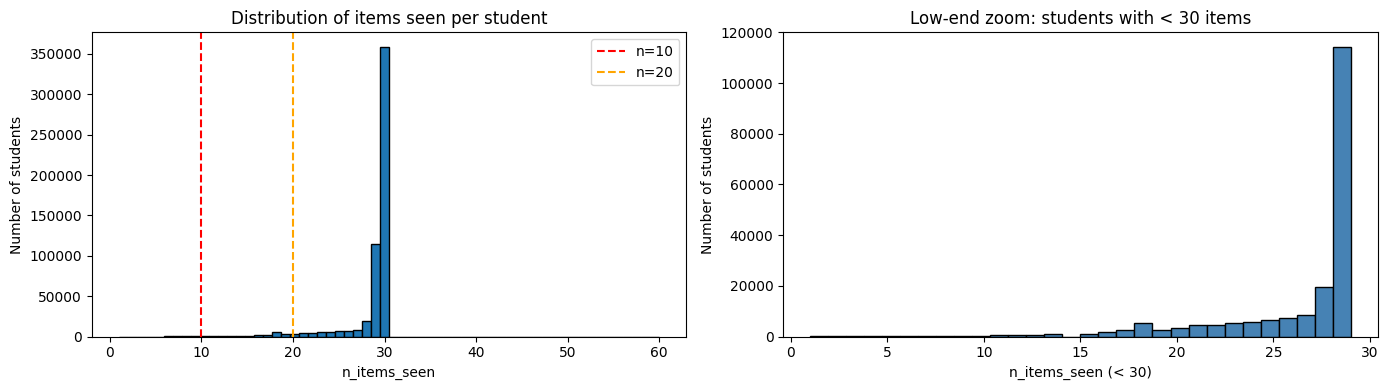

In [6]:
# Detailed distribution of n_items_seen to decide on minimum threshold
print("n_items_seen detailed distribution:")
print(df["n_items_seen"].value_counts().sort_index().head(35))

print("\nCumulative counts at key thresholds:")
for threshold in [1, 5, 10, 15, 20, 25, 29, 30]:
    n_below = (df["n_items_seen"] < threshold).sum()
    pct = n_below / len(df) * 100
    print(f"  n_items_seen < {threshold}: {n_below:,} students ({pct:.2f}%)")

# Visualize distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(df["n_items_seen"], bins=60, edgecolor="black")
ax[0].set_xlabel("n_items_seen")
ax[0].set_ylabel("Number of students")
ax[0].set_title("Distribution of items seen per student")
ax[0].axvline(10, color="red", linestyle="--", label="n=10")
ax[0].axvline(20, color="orange", linestyle="--", label="n=20")
ax[0].legend()

# Zoom into low end
low_end = df[df["n_items_seen"] < 30]
ax[1].hist(low_end["n_items_seen"], bins=30, edgecolor="black", color="steelblue")
ax[1].set_xlabel("n_items_seen (< 30)")
ax[1].set_ylabel("Number of students")
ax[1].set_title("Low-end zoom: students with < 30 items")

plt.tight_layout()
plt.show()

In [7]:
# Tier-1 outlier treatment: Convert TT values > 30 minutes to NaN
# Rationale: Students left the browser tab open, these are system artifacts, not genuine response times
# Threshold: 30 minutes = 1,800,000 ms (only affects 0.0089% of observations per prior diagnostic)
# Important: We modify TT values only; corresponding A, V, F, VS columns are kept as-is
#            because they may still reflect genuine interaction even if total time is suspect.
#            However, for feature computation we will use the cleaned TT values.

TT_OUTLIER_THRESHOLD_MS = 30 * 60 * 1000  # 1,800,000 ms

tt_cols = [c for c in df.columns if c.endswith("TT") and c.startswith("CM")]
print(f"Processing {len(tt_cols)} TT columns...")

# Count observations above threshold BEFORE cleaning
n_above_before = 0
for col in tt_cols:
    n_above_before += (df[col] > TT_OUTLIER_THRESHOLD_MS).sum()

print(f"Observations above 30 min (before cleaning): {n_above_before:,}")

# Apply threshold (vectorized per column to save memory)
for col in tt_cols:
    mask = df[col] > TT_OUTLIER_THRESHOLD_MS
    if mask.any():
        df.loc[mask, col] = np.nan

# Verify
n_above_after = 0
for col in tt_cols:
    n_above_after += (df[col] > TT_OUTLIER_THRESHOLD_MS).sum()

print(f"Observations above 30 min (after cleaning):  {n_above_after:,}")
print_memory()

Processing 234 TT columns...
Observations above 30 min (before cleaning): 1,427
Observations above 30 min (after cleaning):  0
Current memory usage: 0.81 GB


In [8]:
# Recompute n_items_seen after Tier-1 outlier removal
# After setting extreme TT values to NaN, a student may have fewer valid items than originally recorded
# We create n_items_valid: number of items with non-NaN TT values

print("Recomputing n_items_seen after outlier removal...")
df["n_items_valid"] = df[tt_cols].notna().sum(axis=1).astype(np.int16)

# Compare old vs new
print("\nComparison of n_items_seen (original) vs n_items_valid (after cleaning):")
comparison = pd.DataFrame({
    "original": df["n_items_seen"].describe(),
    "after_cleaning": df["n_items_valid"].describe()
})
print(comparison.round(2))

# How many students lost items?
lost = (df["n_items_seen"] - df["n_items_valid"])
print(f"\nStudents who lost at least 1 item: {(lost > 0).sum():,} ({(lost > 0).mean()*100:.2f}%)")
print(f"Max items lost by a single student: {lost.max()}")
print(f"Students with ALL items now NaN: {(df['n_items_valid'] == 0).sum():,}")

Recomputing n_items_seen after outlier removal...

Comparison of n_items_seen (original) vs n_items_valid (after cleaning):
        original  after_cleaning
count  555784.00       555784.00
mean       28.79           28.79
std         2.97            2.98
min         1.00            0.00
25%        29.00           29.00
50%        30.00           30.00
75%        30.00           30.00
max        60.00           60.00

Students who lost at least 1 item: 1,411 (0.25%)
Max items lost by a single student: 2
Students with ALL items now NaN: 9


In [9]:
# Apply minimum item threshold: keep only students with n_items_valid >= 10
# Rationale (for thesis):
# 1. Low item counts may reflect systematic issues (technical problems, early dropout)
#    — completely removing them would introduce bias, but reliable behavioral feature 
#    estimation requires minimum sample size per student
# 2. Linear regression slope (effort_regulation) requires at least 10 data points
#    for meaningful estimation
# 3. Variance-based features (time_cv) are unreliable below ~10 observations
# 4. Sensitivity analysis will compare results with n >= 20 threshold

MIN_ITEMS = 10

print(f"Minimum valid items threshold: {MIN_ITEMS}")
print(f"Before filter: {len(df):,} students")

n_below = (df["n_items_valid"] < MIN_ITEMS).sum()
print(f"Students with n_items_valid < {MIN_ITEMS}: {n_below:,} ({n_below/len(df)*100:.2f}%)")

df = df[df["n_items_valid"] >= MIN_ITEMS].reset_index(drop=True)
print(f"After filter: {len(df):,} students")

# Updated distribution
print(f"\nUpdated n_items_valid distribution:")
print(df["n_items_valid"].describe())
print_memory()

Minimum valid items threshold: 10
Before filter: 555,784 students
Students with n_items_valid < 10: 1,104 (0.20%)
After filter: 554,680 students

Updated n_items_valid distribution:
count    554680.000000
mean         28.837198
std           2.798003
min          10.000000
25%          29.000000
50%          30.000000
75%          30.000000
max          60.000000
Name: n_items_valid, dtype: float64
Current memory usage: 0.56 GB


EFFORTT before winsorization:
count    5.488070e+05
mean     5.899571e+04
std      1.708245e+05
min      6.800000e+01
95%      1.080800e+05
99%      2.329383e+05
99.9%    1.688893e+06
max      7.739432e+07
Name: EFFORTT, dtype: float64

99th percentile cap: 232,938 ms = 3.88 minutes
Values capped: 5,489 (1.00% of non-null)

EFFORTT after winsorization:
count    548807.000000
mean      52555.824219
std       34355.679688
min          68.000000
25%       31526.500000
50%       47289.000000
75%       65471.500000
max      232938.281250
Name: EFFORTT_winsorized, dtype: float64

log_effortt distribution:
count    548807.000000
mean         10.661802
std           0.701721
min           4.234107
25%          10.358616
50%          10.764054
75%          11.089385
max          12.358533
Name: log_effortt, dtype: float64


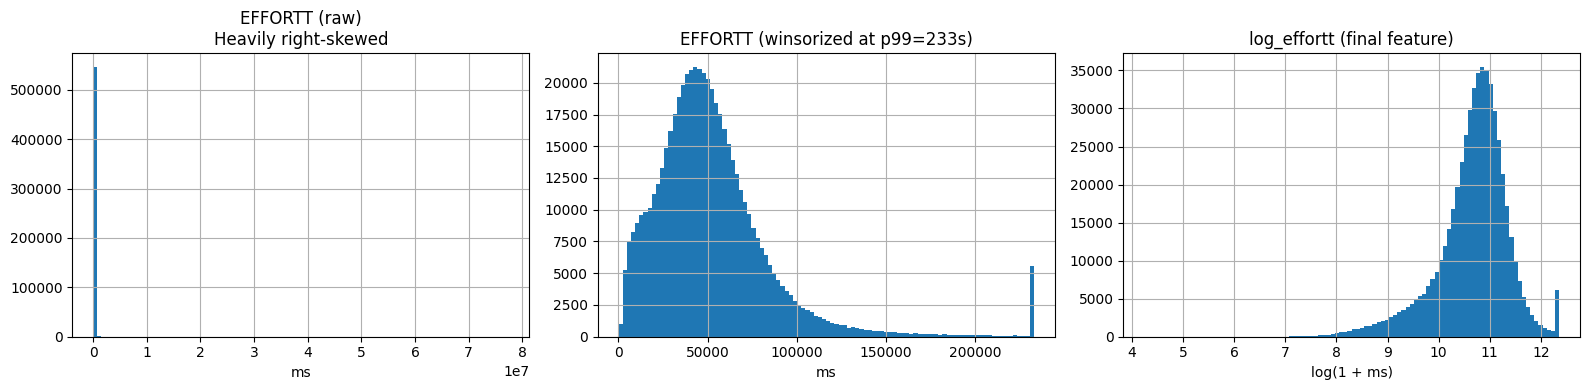

In [10]:
# Tier-3 outlier treatment: EFFORTT
# Decision A1: Winsorize at 99th percentile, then log-transform
# Rationale: EFFORTT is the total response time for "effort thermometer" questionnaire items,
# measured in ms. Distribution is severely right-skewed (max = 77M ms = ~21 hours, clearly a 
# system artifact). The 99th percentile (~3.9 min) represents a plausible upper bound for 
# genuine effort-reporting behavior.

print("EFFORTT before winsorization:")
print(df["EFFORTT"].describe(percentiles=[0.95, 0.99, 0.999]))

# Compute 99th percentile (excluding NaN)
p99_effortt = df["EFFORTT"].quantile(0.99)
print(f"\n99th percentile cap: {p99_effortt:,.0f} ms = {p99_effortt/60000:.2f} minutes")

# Apply winsorization at 99th percentile (one-sided, only upper tail)
# We do NOT winsorize the lower tail because even very low EFFORTT values are meaningful 
# (students who did not engage with effort items — this is substantively interesting, not noise)
n_capped = (df["EFFORTT"] > p99_effortt).sum()
print(f"Values capped: {n_capped:,} ({n_capped/df['EFFORTT'].notna().sum()*100:.2f}% of non-null)")

df["EFFORTT_winsorized"] = df["EFFORTT"].clip(upper=p99_effortt)

# Log-transform (log1p to safely handle low values)
df["log_effortt"] = np.log1p(df["EFFORTT_winsorized"])

print("\nEFFORTT after winsorization:")
print(df["EFFORTT_winsorized"].describe())

print("\nlog_effortt distribution:")
print(df["log_effortt"].describe())

# Quick visual check: before vs after
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["EFFORTT"].dropna().hist(bins=100, ax=axes[0])
axes[0].set_title("EFFORTT (raw)\nHeavily right-skewed")
axes[0].set_xlabel("ms")

df["EFFORTT_winsorized"].dropna().hist(bins=100, ax=axes[1])
axes[1].set_title(f"EFFORTT (winsorized at p99={p99_effortt/1000:.0f}s)")
axes[1].set_xlabel("ms")

df["log_effortt"].dropna().hist(bins=100, ax=axes[2])
axes[2].set_title("log_effortt (final feature)")
axes[2].set_xlabel("log(1 + ms)")

plt.tight_layout()
plt.show()

In [11]:
# Organize process columns by suffix type (TT, A, V, F, VS)
# Each of 234 math items has 5 process columns: CM[item]Q[qid][suffix]

all_process_cols = [c for c in df.columns if c.startswith("CM")]

tt_cols = [c for c in all_process_cols if c.endswith("TT")]
a_cols  = [c for c in all_process_cols if c.endswith("A") and not c.endswith("MA")]
v_cols  = [c for c in all_process_cols if c.endswith("V") and not c.endswith("VS")]
f_cols  = [c for c in all_process_cols if c.endswith("F")]
vs_cols = [c for c in all_process_cols if c.endswith("VS")]

print(f"TT columns (total time):       {len(tt_cols)}")
print(f"A  columns (actions):          {len(a_cols)}")
print(f"V  columns (visits):           {len(v_cols)}")
print(f"F  columns (first-visit dur):  {len(f_cols)}")
print(f"VS columns (visit sequence):   {len(vs_cols)}")
print(f"Total: {len(tt_cols) + len(a_cols) + len(v_cols) + len(f_cols) + len(vs_cols)}")

# Sanity check: A and V columns should each be 234 (watch out for "MA" / "VS" false matches)

TT columns (total time):       234
A  columns (actions):          234
V  columns (visits):           234
F  columns (first-visit dur):  234
VS columns (visit sequence):   234
Total: 1170


In [12]:
# Compute item-specific rapid guessing thresholds
# Threshold per item j = max(0.10 * median(TT_j), 3000 ms)
# - 10% of item median: adapts to item difficulty/length
# - 3000 ms floor: minimum cognitive time to read and respond meaningfully

RAPID_GUESS_FLOOR_MS = 3000  # 3 seconds

print("Computing item-specific rapid guessing thresholds...")

# Compute median TT per item (ignoring NaN)
# Only use non-zero TT values (zero = item not seen)
item_medians = {}
for col in tt_cols:
    valid_values = df[col].dropna()
    valid_values = valid_values[valid_values > 0]
    if len(valid_values) > 0:
        item_medians[col] = valid_values.median()

# Compute thresholds
rapid_guess_thresholds = {}
for col, med in item_medians.items():
    threshold = max(0.10 * med, RAPID_GUESS_FLOOR_MS)
    rapid_guess_thresholds[col] = threshold

# Convert to Series for inspection
thresh_series = pd.Series(rapid_guess_thresholds)
print(f"\nThresholds computed for {len(thresh_series)} items")
print("\nDistribution of item-specific thresholds (ms):")
print(thresh_series.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]))

# How many items hit the floor (threshold = 3000 ms)?
n_at_floor = (thresh_series == RAPID_GUESS_FLOOR_MS).sum()
print(f"\nItems at floor (3000 ms): {n_at_floor} ({n_at_floor/len(thresh_series)*100:.1f}%)")

# Distribution of item medians (for reference)
median_series = pd.Series(item_medians)
print("\nDistribution of item medians (ms):")
print(median_series.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]))

Computing item-specific rapid guessing thresholds...

Thresholds computed for 234 items

Distribution of item-specific thresholds (ms):
count      234.000000
mean      7365.049675
std       2713.945505
min       3000.000000
5%        3696.960083
25%       5313.337769
50%       7149.650146
75%       9063.787354
95%      11985.239941
max      17601.099609
dtype: float64

Items at floor (3000 ms): 5 (2.1%)

Distribution of item medians (ms):
count       234.000000
mean      73611.640625
std       27205.839844
min       23292.500000
5%        36969.600000
25%       53133.375000
50%       71496.500000
75%       90637.875000
95%      119852.400000
max      176011.000000
dtype: float64


In [13]:
# Organize process columns by suffix type (TT, A, V, F, VS)
# Each of 234 math items has 5 process columns: CM[item]Q[qid][suffix]

all_process_cols = [c for c in df.columns if c.startswith("CM")]

tt_cols = [c for c in all_process_cols if c.endswith("TT")]
# Careful with suffix matching: "V" vs "VS" collision
v_cols  = [c for c in all_process_cols if c.endswith("V") and not c.endswith("VS")]
vs_cols = [c for c in all_process_cols if c.endswith("VS")]
# For A (actions), exclude other potential two-letter endings
a_cols  = [c for c in all_process_cols if c.endswith("A")]
f_cols  = [c for c in all_process_cols if c.endswith("F")]

print(f"TT columns (total time):       {len(tt_cols)}")
print(f"A  columns (actions):          {len(a_cols)}")
print(f"V  columns (visits):           {len(v_cols)}")
print(f"F  columns (first-visit dur):  {len(f_cols)}")
print(f"VS columns (visit sequence):   {len(vs_cols)}")
total = len(tt_cols) + len(a_cols) + len(v_cols) + len(f_cols) + len(vs_cols)
print(f"\nTotal process columns: {total} (expected: 1170)")

# Sanity check — each should be 234
assert len(tt_cols) == 234, f"Expected 234 TT cols, got {len(tt_cols)}"

TT columns (total time):       234
A  columns (actions):          234
V  columns (visits):           234
F  columns (first-visit dur):  234
VS columns (visit sequence):   234

Total process columns: 1170 (expected: 1170)


In [14]:
# Literature-based benchmark feature: NT15 with 5-sec floor
# Method: Michaelides & Ivanova (2022) applied to PISA 2015 Math
# Threshold_j = max(0.15 * median(TT_j), 5000 ms)
# This serves as SENSITIVITY ANALYSIS against the mixture-based System 1 probability

RAPID_GUESS_FLOOR_MS = 5000  # 5 seconds (Michaelides & Ivanova 2022; Wise 2019)
NT_COEFFICIENT = 0.15        # 15% of item median

print("Computing NT15 item-specific rapid guessing thresholds...")

item_medians = {}
for col in tt_cols:
    valid_values = df[col].dropna()
    valid_values = valid_values[valid_values > 0]
    if len(valid_values) > 0:
        item_medians[col] = valid_values.median()

rapid_guess_thresholds_nt15 = {}
for col, med in item_medians.items():
    threshold = max(NT_COEFFICIENT * med, RAPID_GUESS_FLOOR_MS)
    rapid_guess_thresholds_nt15[col] = threshold

thresh_series = pd.Series(rapid_guess_thresholds_nt15)
print(f"\nThresholds computed for {len(thresh_series)} items")
print("\nNT15 threshold distribution (ms):")
print(thresh_series.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]))

n_at_floor = (thresh_series == RAPID_GUESS_FLOOR_MS).sum()
print(f"\nItems at floor (5000 ms): {n_at_floor} ({n_at_floor/len(thresh_series)*100:.1f}%)")

median_series = pd.Series(item_medians)
print("\nItem median TT distribution (ms):")
print(median_series.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]))

Computing NT15 item-specific rapid guessing thresholds...

Thresholds computed for 234 items

NT15 threshold distribution (ms):
count      234.000000
mean     11060.629808
std       4050.588006
min       5000.000000
5%        5545.440161
25%       7970.006470
50%      10724.475098
75%      13595.681641
95%      17977.861035
max      26401.650391
dtype: float64

Items at floor (5000 ms): 7 (3.0%)

Item median TT distribution (ms):
count       234.000000
mean      73611.640625
std       27205.839844
min       23292.500000
5%        36969.600000
25%       53133.375000
50%       71496.500000
75%       90637.875000
95%      119852.400000
max      176011.000000
dtype: float64


In [15]:
# Compute rapid_guess_ratio per student using NT15 threshold
# This feature will be used in sensitivity analysis (thesis methodology section)

print("Computing rapid_guess_ratio_nt15 per student...")

rapid_guess_counts_nt15 = pd.Series(0, index=df.index, dtype=np.int32)

for col in tt_cols:
    threshold = rapid_guess_thresholds_nt15[col]
    rapid_flag = (df[col] > 0) & (df[col] < threshold) & df[col].notna()
    rapid_guess_counts_nt15 += rapid_flag.astype(np.int32)

df["rapid_guess_count_nt15"] = rapid_guess_counts_nt15
df["rapid_guess_ratio_nt15"] = df["rapid_guess_count_nt15"] / df["n_items_valid"]

print(f"\nrapid_guess_ratio_nt15 distribution:")
print(df["rapid_guess_ratio_nt15"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

print(f"\nStudents with ratio == 0:      {(df['rapid_guess_ratio_nt15'] == 0).sum():,} ({(df['rapid_guess_ratio_nt15'] == 0).mean()*100:.2f}%)")
print(f"Students with ratio > 0.10:    {(df['rapid_guess_ratio_nt15'] > 0.10).sum():,} ({(df['rapid_guess_ratio_nt15'] > 0.10).mean()*100:.2f}%)")
print(f"Students with ratio > 0.50:    {(df['rapid_guess_ratio_nt15'] > 0.50).sum():,} ({(df['rapid_guess_ratio_nt15'] > 0.50).mean()*100:.2f}%)")

print_memory()

Computing rapid_guess_ratio_nt15 per student...

rapid_guess_ratio_nt15 distribution:
count    554680.000000
mean          0.070596
std           0.136074
min           0.000000
5%            0.000000
25%           0.000000
50%           0.000000
75%           0.068966
95%           0.366667
99%           0.666667
max           1.000000
Name: rapid_guess_ratio_nt15, dtype: float64

Students with ratio == 0:      308,591 (55.63%)
Students with ratio > 0.10:    113,155 (20.40%)
Students with ratio > 0.50:    12,824 (2.31%)
Current memory usage: 0.65 GB


In [16]:
# Primary feature: System 1 probability via Gaussian Mixture Model on log(TT)
# Conceptual foundation: Dual-Process Theory
# - Component 1 (lower mean)  = System 1 (heuristic, rapid, automatic processing)
# - Component 2 (higher mean) = System 2 (analytical, deliberate, slow processing)
# 
# For each item j, fit 2-component GMM on log(TT_ij) where TT_ij > 0 and not NaN
# Store component means, weights, and BIC for model diagnostics

from sklearn.mixture import GaussianMixture
import time

print(f"Fitting 2-component Gaussian Mixture Models on {len(tt_cols)} items...")
print("This will take a few minutes.")

# Storage for model parameters (for thesis appendix and diagnostics)
gmm_models = {}   # item_col -> fitted GMM object
gmm_diagnostics = []  # list of dicts for DataFrame

start_time = time.time()

for idx, col in enumerate(tt_cols):
    # Extract valid positive TT values
    values = df[col].dropna()
    values = values[values > 0].values
    
    if len(values) < 100:
        # Too few observations for reliable fit — skip
        gmm_diagnostics.append({
            "item": col, "n_obs": len(values), "converged": False,
            "bic_2comp": np.nan, "bic_1comp": np.nan,
            "mean_sys1": np.nan, "mean_sys2": np.nan,
            "weight_sys1": np.nan, "weight_sys2": np.nan,
            "prefer_2comp": False
        })
        continue
    
    # Transform: log(TT) — essential because RT is log-normal
    log_values = np.log(values).reshape(-1, 1)
    
    try:
        # Fit 2-component GMM
        gmm_2 = GaussianMixture(
            n_components=2, 
            covariance_type="full", 
            random_state=42,
            max_iter=200,
            n_init=3  # multiple initializations to avoid local optima
        )
        gmm_2.fit(log_values)
        
        # Fit 1-component as baseline for model selection
        gmm_1 = GaussianMixture(
            n_components=1, covariance_type="full", random_state=42
        )
        gmm_1.fit(log_values)
        
        # Identify which component is System 1 (lower mean = faster)
        means = gmm_2.means_.flatten()
        weights = gmm_2.weights_
        
        sys1_idx = np.argmin(means)
        sys2_idx = np.argmax(means)
        
        # Store model with System 1 index marked
        gmm_models[col] = {
            "model": gmm_2,
            "sys1_idx": sys1_idx,
            "sys2_idx": sys2_idx
        }
        
        gmm_diagnostics.append({
            "item": col,
            "n_obs": len(values),
            "converged": gmm_2.converged_,
            "bic_2comp": gmm_2.bic(log_values),
            "bic_1comp": gmm_1.bic(log_values),
            "mean_sys1": np.exp(means[sys1_idx]),  # back to ms for interpretation
            "mean_sys2": np.exp(means[sys2_idx]),
            "weight_sys1": weights[sys1_idx],
            "weight_sys2": weights[sys2_idx],
            "prefer_2comp": gmm_2.bic(log_values) < gmm_1.bic(log_values)
        })
        
    except Exception as e:
        gmm_diagnostics.append({
            "item": col, "n_obs": len(values), "converged": False,
            "bic_2comp": np.nan, "bic_1comp": np.nan,
            "mean_sys1": np.nan, "mean_sys2": np.nan,
            "weight_sys1": np.nan, "weight_sys2": np.nan,
            "prefer_2comp": False
        })
    
    # Progress update every 50 items
    if (idx + 1) % 50 == 0:
        elapsed = time.time() - start_time
        print(f"  {idx+1}/{len(tt_cols)} items done ({elapsed:.0f}s elapsed)")

elapsed = time.time() - start_time
print(f"\nTotal fitting time: {elapsed:.1f}s")
print(f"Successfully fit models: {len(gmm_models)} / {len(tt_cols)}")

# Diagnostics DataFrame
gmm_diag_df = pd.DataFrame(gmm_diagnostics)
print("\nDiagnostics summary:")
print(f"Items where 2-component preferred (BIC): {gmm_diag_df['prefer_2comp'].sum()} / {len(gmm_diag_df)}")
print(f"Items converged: {gmm_diag_df['converged'].sum()} / {len(gmm_diag_df)}")

print("\nSystem 1 component statistics (ms):")
print(gmm_diag_df["mean_sys1"].describe())
print("\nSystem 2 component statistics (ms):")
print(gmm_diag_df["mean_sys2"].describe())
print("\nSystem 1 weight (proportion of rapid-mode responses per item):")
print(gmm_diag_df["weight_sys1"].describe())

print_memory()

Fitting 2-component Gaussian Mixture Models on 234 items...
This will take a few minutes.
  50/234 items done (13s elapsed)
  100/234 items done (24s elapsed)
  150/234 items done (34s elapsed)
  200/234 items done (45s elapsed)

Total fitting time: 51.7s
Successfully fit models: 234 / 234

Diagnostics summary:
Items where 2-component preferred (BIC): 234 / 234
Items converged: 234 / 234

System 1 component statistics (ms):
count      234.000000
mean     19078.500000
std      14189.579102
min       2059.123779
25%      10341.955078
50%      14137.177246
75%      21693.945801
max      71901.750000
Name: mean_sys1, dtype: float64

System 2 component statistics (ms):
count       234.000000
mean      86388.203125
std       30999.515625
min       24241.941406
25%       64442.333008
50%       82752.132812
75%      106079.507812
max      183724.734375
Name: mean_sys2, dtype: float64

System 1 weight (proportion of rapid-mode responses per item):
count    234.000000
mean       0.208109
std    

In [18]:
# Compute P(System 1 | TT_ij) for each observation, then aggregate per student
# For each student i, each item j with valid TT:
#   p_sys1_ij = posterior probability that the observation belongs to System 1 component
#   = w_sys1 * pdf_sys1(log(TT_ij)) / [w_sys1 * pdf_sys1(log(TT_ij)) + w_sys2 * pdf_sys2(log(TT_ij))]
#
# Student-level aggregation: mean of p_sys1 across items the student saw
# This produces `system1_probability` — the primary dual-process feature

print("Computing per-observation System 1 posterior probabilities...")
print("Then aggregating to student level.")

# We build a matrix of p_sys1 values with the same shape as df[tt_cols]
# Then take row-wise mean (ignoring NaN) — this gives system1_probability per student

# Strategy: process item by item, store per-item mean probability contribution
# We accumulate sum of p_sys1 and count of valid observations per student

p_sys1_sum = np.zeros(len(df), dtype=np.float64)
p_sys1_count = np.zeros(len(df), dtype=np.int32)

# Also store per-item mean p_sys1 for diagnostics (how "rapid" each item was on average)
per_item_p_sys1_mean = {}

start_time = time.time()

for idx, col in enumerate(tt_cols):
    if col not in gmm_models:
        continue  # item was skipped during fitting
    
    gmm_info = gmm_models[col]
    gmm = gmm_info["model"]
    sys1_idx = gmm_info["sys1_idx"]
    
    # Get valid TT values with their student positions
    tt_values = df[col].values
    valid_mask = (~np.isnan(tt_values)) & (tt_values > 0)
    
    if valid_mask.sum() == 0:
        continue
    
    # Transform to log for GMM prediction
    log_tt_valid = np.log(tt_values[valid_mask]).reshape(-1, 1)
    
    # Posterior probabilities for both components
    posteriors = gmm.predict_proba(log_tt_valid)  # shape: (n_valid, 2)
    p_sys1_valid = posteriors[:, sys1_idx]
    
    # Accumulate in student vectors
    p_sys1_sum[valid_mask] += p_sys1_valid
    p_sys1_count[valid_mask] += 1
    
    # Per-item diagnostic
    per_item_p_sys1_mean[col] = p_sys1_valid.mean()
    
    if (idx + 1) % 50 == 0:
        elapsed = time.time() - start_time
        print(f"  {idx+1}/{len(tt_cols)} items processed ({elapsed:.0f}s elapsed)")

elapsed = time.time() - start_time
print(f"\nTotal processing time: {elapsed:.1f}s")

# Final student-level System 1 probability (average across valid items)
# Note: p_sys1_count should equal n_items_valid for all students (sanity check)
with np.errstate(divide="ignore", invalid="ignore"):
    system1_probability = np.where(p_sys1_count > 0, p_sys1_sum / p_sys1_count, np.nan)

df["system1_probability"] = system1_probability.astype(np.float32)

# Sanity check: p_sys1_count vs n_items_valid
count_mismatch = (p_sys1_count != df["n_items_valid"].values).sum()
print(f"\nSanity check — students with p_sys1_count != n_items_valid: {count_mismatch}")

print("\nsystem1_probability distribution:")
print(df["system1_probability"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

print(f"\nMissing values: {df['system1_probability'].isna().sum()}")

print_memory()

Computing per-observation System 1 posterior probabilities...
Then aggregating to student level.
  50/234 items processed (1s elapsed)
  100/234 items processed (2s elapsed)
  150/234 items processed (3s elapsed)
  200/234 items processed (4s elapsed)

Total processing time: 4.6s

Sanity check — students with p_sys1_count != n_items_valid: 0

system1_probability distribution:
count    554680.000000
mean          0.208875
std           0.175925
min           0.011519
5%            0.054564
25%           0.089004
50%           0.144215
75%           0.264009
95%           0.599507
99%           0.855038
max           1.000000
Name: system1_probability, dtype: float64

Missing values: 0
Current memory usage: 0.75 GB


Comparison: rapid_guess_ratio_nt15 vs system1_probability

Pearson correlation:  0.8933
Spearman correlation: 0.7986

Cross-tabulation (binary NT15 rapid guesser vs mixture quartile):
system1_probability     Q1 (lowest S1)      Q2      Q3  Q4 (highest S1)   Total
rapid_guess_ratio_nt15                                                         
None                            136052  111164   55078             6297  308591
Low (0-10%)                       2618   27439   68302            34575  132934
Moderate (10-50%)                    0      67   15290            84974  100331
High (>50%)                          0       0       0            12824   12824
Total                           138670  138670  138670           138670  554680

Key finding — System 1 probability for students with rapid_guess_ratio_nt15 == 0:
count    308591.000000
mean          0.109061
std           0.054966
min           0.011519
25%           0.070794
50%           0.095208
75%           0.132086
max         

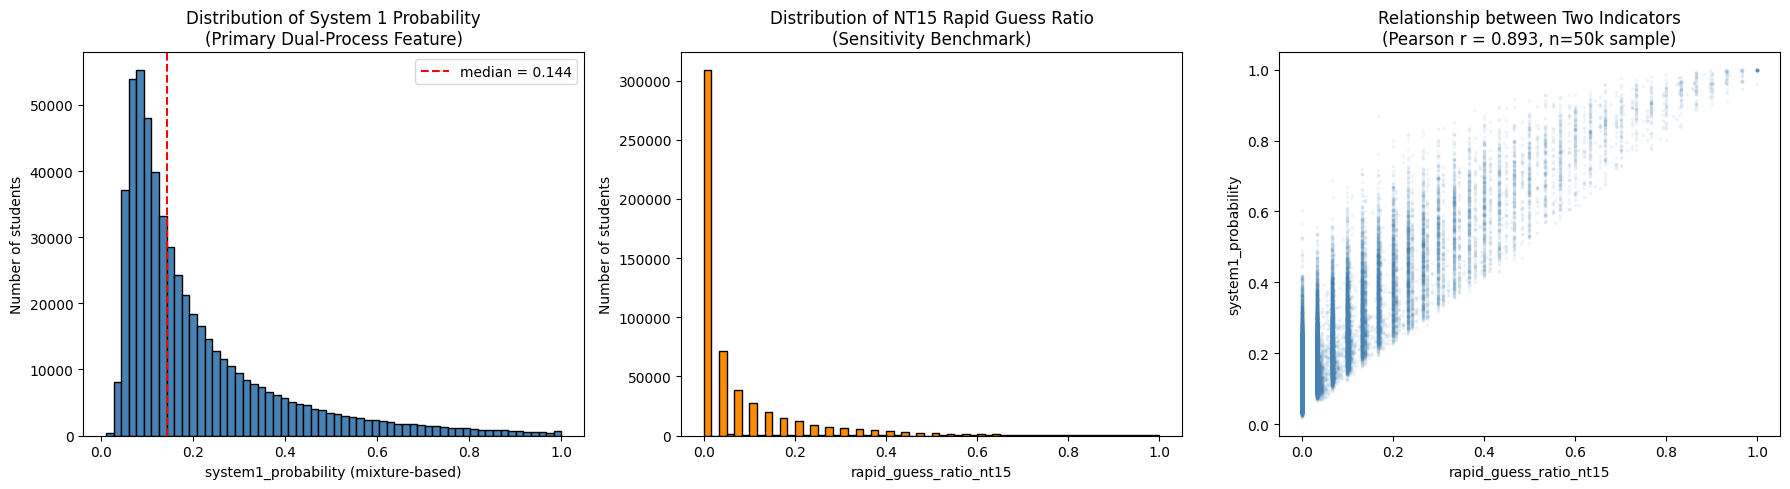

In [19]:
# Compare NT15-based rapid_guess_ratio vs mixture-based system1_probability
# This comparison is a thesis finding: do these two conceptually different 
# operationalizations converge or diverge?

print("Comparison: rapid_guess_ratio_nt15 vs system1_probability")
print("="*60)

# Correlation
pearson_corr = df[["rapid_guess_ratio_nt15", "system1_probability"]].corr(method="pearson").iloc[0, 1]
spearman_corr = df[["rapid_guess_ratio_nt15", "system1_probability"]].corr(method="spearman").iloc[0, 1]

print(f"\nPearson correlation:  {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")

# Cross-tabulation
print("\nCross-tabulation (binary NT15 rapid guesser vs mixture quartile):")
nt15_category = pd.cut(df["rapid_guess_ratio_nt15"], 
                        bins=[-0.001, 0.001, 0.10, 0.50, 1.01],
                        labels=["None", "Low (0-10%)", "Moderate (10-50%)", "High (>50%)"])
mixture_quartile = pd.qcut(df["system1_probability"], q=4, 
                            labels=["Q1 (lowest S1)", "Q2", "Q3", "Q4 (highest S1)"])

crosstab = pd.crosstab(nt15_category, mixture_quartile, margins=True, margins_name="Total")
print(crosstab)

# Key finding: What does system1_probability look like for students NT15 classified as "None"?
print("\nKey finding — System 1 probability for students with rapid_guess_ratio_nt15 == 0:")
zero_nt15_mask = df["rapid_guess_ratio_nt15"] == 0
print(df.loc[zero_nt15_mask, "system1_probability"].describe())

print("\nThis shows that NT15 collapses ~55% of students into 'None' category,")
print("but the mixture model reveals substantial variation within this group.")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: distribution of system1_probability
axes[0].hist(df["system1_probability"].dropna(), bins=60, edgecolor="black", color="steelblue")
axes[0].set_xlabel("system1_probability (mixture-based)")
axes[0].set_ylabel("Number of students")
axes[0].set_title("Distribution of System 1 Probability\n(Primary Dual-Process Feature)")
axes[0].axvline(df["system1_probability"].median(), color="red", linestyle="--", label=f"median = {df['system1_probability'].median():.3f}")
axes[0].legend()

# Middle: distribution of rapid_guess_ratio_nt15
axes[1].hist(df["rapid_guess_ratio_nt15"], bins=60, edgecolor="black", color="darkorange")
axes[1].set_xlabel("rapid_guess_ratio_nt15")
axes[1].set_ylabel("Number of students")
axes[1].set_title("Distribution of NT15 Rapid Guess Ratio\n(Sensitivity Benchmark)")

# Right: scatter relationship (sample for readability)
sample_idx = np.random.RandomState(42).choice(len(df), size=50000, replace=False)
axes[2].scatter(df["rapid_guess_ratio_nt15"].iloc[sample_idx], 
                df["system1_probability"].iloc[sample_idx],
                alpha=0.05, s=3, color="steelblue")
axes[2].set_xlabel("rapid_guess_ratio_nt15")
axes[2].set_ylabel("system1_probability")
axes[2].set_title(f"Relationship between Two Indicators\n(Pearson r = {pearson_corr:.3f}, n=50k sample)")

plt.tight_layout()
plt.show()

In [20]:
# Compute time-based behavioral features aggregated at student level
# Using the cleaned TT columns (after Tier-1 outlier removal)
# All features computed with ignore-NaN logic (skipna equivalent)

print("Computing time-based behavioral features...")

# Extract TT matrix for vectorized computation
tt_matrix = df[tt_cols].values  # shape: (n_students, 234)
# Replace 0 with NaN so they don't affect aggregation
tt_matrix_clean = np.where(tt_matrix > 0, tt_matrix, np.nan)

# 1. Total time across all items (log-transformed)
total_time = np.nansum(tt_matrix_clean, axis=1)
df["log_total_time"] = np.log1p(total_time).astype(np.float32)

# 2. Mean time per item (log-transformed)
mean_time = np.nanmean(tt_matrix_clean, axis=1)
df["log_mean_time_per_item"] = np.log1p(mean_time).astype(np.float32)

# 3. Time coefficient of variation (time_cv = std/mean, per student)
# System 2 metacognitive monitoring: high cv = student adjusts time per item difficulty
std_time = np.nanstd(tt_matrix_clean, axis=1, ddof=1)
time_cv = std_time / mean_time
df["time_cv"] = time_cv.astype(np.float32)

print("\nTime-based features:")
print(df[["log_total_time", "log_mean_time_per_item", "time_cv"]].describe())

print_memory()

Computing time-based behavioral features...

Time-based features:
       log_total_time  log_mean_time_per_item        time_cv
count   554680.000000           554680.000000  554680.000000
mean        14.675065               11.319756       0.819935
std          0.460137                0.492656       0.331489
min         10.035568                6.802765       0.175942
25%         14.529296               11.143821       0.615498
50%         14.817430               11.434177       0.741086
75%         14.970543               11.606323       0.924783
max         16.253117               13.007051       5.323043
Current memory usage: 1.23 GB


In [21]:
# Compute time-based behavioral features aggregated at student level
# Using the cleaned TT columns (after Tier-1 outlier removal)
# All features computed with ignore-NaN logic (skipna equivalent)

print("Computing time-based behavioral features...")

# Extract TT matrix for vectorized computation
tt_matrix = df[tt_cols].values  # shape: (n_students, 234)
# Replace 0 with NaN so they don't affect aggregation
tt_matrix_clean = np.where(tt_matrix > 0, tt_matrix, np.nan)

# 1. Total time across all items (log-transformed)
total_time = np.nansum(tt_matrix_clean, axis=1)
df["log_total_time"] = np.log1p(total_time).astype(np.float32)

# 2. Mean time per item (log-transformed)
mean_time = np.nanmean(tt_matrix_clean, axis=1)
df["log_mean_time_per_item"] = np.log1p(mean_time).astype(np.float32)

# 3. Time coefficient of variation (time_cv = std/mean, per student)
# System 2 metacognitive monitoring: high cv = student adjusts time per item difficulty
std_time = np.nanstd(tt_matrix_clean, axis=1, ddof=1)
time_cv = std_time / mean_time
df["time_cv"] = time_cv.astype(np.float32)

print("\nTime-based features:")
print(df[["log_total_time", "log_mean_time_per_item", "time_cv"]].describe())

print_memory()

Computing time-based behavioral features...

Time-based features:
       log_total_time  log_mean_time_per_item        time_cv
count   554680.000000           554680.000000  554680.000000
mean        14.675065               11.319756       0.819935
std          0.460137                0.492656       0.331489
min         10.035568                6.802765       0.175942
25%         14.529296               11.143821       0.615498
50%         14.817430               11.434177       0.741086
75%         14.970543               11.606323       0.924783
max         16.253117               13.007051       5.323043
Current memory usage: 1.34 GB


In [23]:
# Effort regulation: slope of log(TT) as a function of item order within each student
# Negative slope = decreasing effort over test (fatigue/motivation drop)
# Positive slope = warming up

# Important: PISA uses balanced booklet design; item column order in parquet reflects 
# the PHYSICAL presentation order (since they were extracted in fixed column sequence).
# For a more refined version, we would use actual test-delivery order per student, 
# but this requires additional metadata. Here we use column order as a proxy.

# Methodology note for thesis: "Effort regulation was operationalized as the linear 
# regression slope of log-transformed response time against item presentation order, 
# computed per student. This captures within-student trajectory of time allocation."

print("Computing effort_regulation (slope of log(TT) ~ item_order)...")
print("This may take 30-60 seconds for 554,680 students.")

# Vectorized slope computation per student
# For each row: slope = cov(x, log(tt)) / var(x), where x = valid item indices
# Using only non-NaN values per student

log_tt_matrix = np.log(tt_matrix_clean)  # log of cleaned TT matrix
n_students = log_tt_matrix.shape[0]

# Column indices (0, 1, 2, ..., 233) serve as "item order"
item_order = np.arange(len(tt_cols), dtype=np.float64)

# Precompute
effort_slopes = np.full(n_students, np.nan, dtype=np.float32)

start_time = time.time()

# Process in chunks to manage memory and show progress
chunk_size = 50000
for chunk_start in range(0, n_students, chunk_size):
    chunk_end = min(chunk_start + chunk_size, n_students)
    chunk = log_tt_matrix[chunk_start:chunk_end]
    
    for i in range(chunk.shape[0]):
        row = chunk[i]
        valid = ~np.isnan(row)
        if valid.sum() < 10:
            continue  # safeguard, should not happen after our filter
        x = item_order[valid]
        y = row[valid]
        # Linear regression slope
        x_mean = x.mean()
        y_mean = y.mean()
        x_var = ((x - x_mean) ** 2).sum()
        if x_var == 0:
            continue
        slope = ((x - x_mean) * (y - y_mean)).sum() / x_var
        effort_slopes[chunk_start + i] = slope
    
    elapsed = time.time() - start_time
    print(f"  {chunk_end:,}/{n_students:,} students processed ({elapsed:.0f}s elapsed)")

df["effort_regulation"] = effort_slopes

print(f"\nTotal time: {time.time() - start_time:.1f}s")
print("\neffort_regulation distribution (slope of log(TT) vs item order):")
print(df["effort_regulation"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]))

# Interpretation helpers
n_negative = (df["effort_regulation"] < 0).sum()
n_positive = (df["effort_regulation"] > 0).sum()
n_zero = (df["effort_regulation"] == 0).sum()
print(f"\nStudents with declining time (negative slope, potential fatigue): {n_negative:,} ({n_negative/len(df)*100:.1f}%)")
print(f"Students with increasing time (positive slope, warming up):        {n_positive:,} ({n_positive/len(df)*100:.1f}%)")

print_memory()

Computing effort_regulation (slope of log(TT) ~ item_order)...
This may take 30-60 seconds for 554,680 students.
  50,000/554,680 students processed (1s elapsed)
  100,000/554,680 students processed (2s elapsed)
  150,000/554,680 students processed (2s elapsed)
  200,000/554,680 students processed (3s elapsed)
  250,000/554,680 students processed (4s elapsed)
  300,000/554,680 students processed (4s elapsed)
  350,000/554,680 students processed (5s elapsed)
  400,000/554,680 students processed (6s elapsed)
  450,000/554,680 students processed (7s elapsed)
  500,000/554,680 students processed (7s elapsed)
  550,000/554,680 students processed (8s elapsed)
  554,680/554,680 students processed (8s elapsed)

Total time: 8.2s

effort_regulation distribution (slope of log(TT) vs item order):
count    554680.000000
mean         -0.000676
std           0.003518
min          -0.044864
5%           -0.006128
25%          -0.002354
50%          -0.000511
75%           0.001174
95%           0.0039

In [24]:
# Visit and action behavioral features
# - mean_visits_per_item: overall revisit tendency (metacognitive review)
# - revisit_ratio: proportion of items visited more than once (categorical revisit)
# - mean_actions_per_item: interaction intensity (problem-solving engagement)
# - first_visit_completion_ratio: F/TT ratio (one-pass vs fragmented work)

print("Computing visit and action features...")

# Extract matrices
v_matrix = df[v_cols].values.astype(np.float32)
a_matrix = df[a_cols].values.astype(np.float32)
f_matrix = df[f_cols].values.astype(np.float32)

# Clean: 0 and NaN both mean "no engagement with item"
v_matrix_clean = np.where((v_matrix > 0) & ~np.isnan(v_matrix), v_matrix, np.nan)
a_matrix_clean = np.where((a_matrix > 0) & ~np.isnan(a_matrix), a_matrix, np.nan)
f_matrix_clean = np.where((f_matrix > 0) & ~np.isnan(f_matrix), f_matrix, np.nan)

# 1. Mean visits per item
df["mean_visits_per_item"] = np.nanmean(v_matrix_clean, axis=1).astype(np.float32)

# 2. Revisit ratio — proportion of items visited > 1 times
# Numerator: items with V > 1, Denominator: items with any valid V (== n_items_valid)
revisit_counts = np.nansum((v_matrix_clean > 1).astype(np.float32), axis=1)
df["revisit_ratio"] = (revisit_counts / df["n_items_valid"]).astype(np.float32)

# 3. Mean actions per item
df["mean_actions_per_item"] = np.nanmean(a_matrix_clean, axis=1).astype(np.float32)

# 4. First-visit completion ratio — F/TT per item, averaged across items
# Only compute where both F and TT are valid and TT > 0
with np.errstate(divide="ignore", invalid="ignore"):
    fvt_ratio_matrix = f_matrix_clean / tt_matrix_clean
# Clip to [0, 1] — ratio should be at most 1 (F is part of TT)
# Values > 1 are likely data artifacts; cap at 1
fvt_ratio_matrix = np.clip(fvt_ratio_matrix, 0, 1)
df["first_visit_completion_ratio"] = np.nanmean(fvt_ratio_matrix, axis=1).astype(np.float32)

print("\nVisit and action features:")
print(df[["mean_visits_per_item", "revisit_ratio", 
         "mean_actions_per_item", "first_visit_completion_ratio"]].describe())

# Free memory
del v_matrix, a_matrix, f_matrix
del v_matrix_clean, a_matrix_clean, f_matrix_clean, fvt_ratio_matrix
gc.collect()
print_memory()

Computing visit and action features...

Visit and action features:
       mean_visits_per_item  revisit_ratio  mean_actions_per_item  first_visit_completion_ratio
count         554680.000000  554680.000000          554654.000000                 554654.000000
mean               1.139307       0.094678              17.049274                      0.514382
std                0.202505       0.108994              13.452430                      0.124094
min                1.000000       0.000000               1.000000                      0.000435
25%                1.000000       0.000000               9.000000                      0.436027
50%                1.066667       0.066667              14.344828                      0.522066
75%                1.200000       0.137931              21.964285                      0.602032
max                8.090909       1.000000            2338.103516                      0.958970
Current memory usage: 0.97 GB


In [25]:
# Tier-2 outlier treatment for mean_actions_per_item
# Max was 2338 — clearly a system artifact (auto-clicks, stuck sessions, etc.)
# Strategy: winsorize at 99th percentile, then log-transform

print("mean_actions_per_item before winsorization:")
print(df["mean_actions_per_item"].describe(percentiles=[0.95, 0.99, 0.999]))

p99_actions = df["mean_actions_per_item"].quantile(0.99)
p999_actions = df["mean_actions_per_item"].quantile(0.999)
print(f"\n99th percentile:    {p99_actions:.2f}")
print(f"99.9th percentile:  {p999_actions:.2f}")

n_above_p99 = (df["mean_actions_per_item"] > p99_actions).sum()
print(f"Values above p99:   {n_above_p99:,} ({n_above_p99/len(df)*100:.2f}%)")

# Winsorize at 99th percentile
df["mean_actions_per_item"] = df["mean_actions_per_item"].clip(upper=p99_actions)

# Log-transform (primary feature for ML modeling)
df["log_mean_actions"] = np.log1p(df["mean_actions_per_item"]).astype(np.float32)

print("\nmean_actions_per_item after winsorization:")
print(df["mean_actions_per_item"].describe())

print("\nlog_mean_actions distribution:")
print(df["log_mean_actions"].describe())

mean_actions_per_item before winsorization:
count    554654.000000
mean         17.049274
std          13.452430
min           1.000000
95%          38.133335
99%          56.133335
99.9%        99.905785
max        2338.103516
Name: mean_actions_per_item, dtype: float64

99th percentile:    56.13
99.9th percentile:  99.91
Values above p99:   5,545 (1.00%)

mean_actions_per_item after winsorization:
count    554654.000000
mean         16.823303
std          10.665640
min           1.000000
25%           9.000000
50%          14.344828
75%          21.964285
max          56.133335
Name: mean_actions_per_item, dtype: float64

log_mean_actions distribution:
count    554654.000000
mean          2.710017
std           0.594600
min           0.693147
25%           2.302585
50%           2.730778
75%           3.133940
max           4.045388
Name: log_mean_actions, dtype: float64


In [27]:
# Diagnostic: investigate what first_visit_completion_ratio actually measures
# Check a few items' F vs TT distributions to understand the relationship

print("Diagnostic: F (first-visit duration) vs TT (total time) relationship")

# Sample 5 items and examine F/TT ratio distribution
sample_items = tt_cols[:5]

for tt_col in sample_items:
    # Find matching F column (same item prefix)
    item_prefix = tt_col[:-2]  # remove "TT"
    f_col = item_prefix + "F"
    
    if f_col not in f_cols:
        continue
    
    # Get valid pairs
    tt_vals = df[tt_col].values
    f_vals = df[f_col].values
    mask = (~np.isnan(tt_vals)) & (~np.isnan(f_vals)) & (tt_vals > 0) & (f_vals > 0)
    
    if mask.sum() == 0:
        continue
    
    ratios = f_vals[mask] / tt_vals[mask]
    n_equal = ((ratios > 0.99) & (ratios <= 1.0)).sum()  # F essentially equals TT
    n_over_1 = (ratios > 1.0).sum()  # F > TT (anomaly)
    n_far_below = (ratios < 0.5).sum()  # F much less than TT
    
    print(f"\n{tt_col} vs {f_col}:")
    print(f"  n valid pairs: {mask.sum():,}")
    print(f"  F/TT median:   {np.median(ratios):.3f}")
    print(f"  F == TT (>0.99): {n_equal:,} ({n_equal/mask.sum()*100:.1f}%) — single-visit items")
    print(f"  F > TT (>1.00):  {n_over_1:,} ({n_over_1/mask.sum()*100:.1f}%) — anomalies")
    print(f"  F/TT < 0.5:      {n_far_below:,} ({n_far_below/mask.sum()*100:.1f}%) — multi-visit items")

# Explanation of why student-level mean is 0.52
print("\n" + "="*60)
print("Interpretation:")
print("first_visit_completion_ratio measures what proportion of total item time")
print("was spent in the FIRST visit. Values near 1.0 mean single-visit completion;")
print("values near 0.5 suggest substantial revisiting/fragmented work.")
print("Student median of 0.52 suggests PISA students frequently revisit items.")
print("This is consistent with our revisit_ratio finding that 9.5% of items per")
print("student (on average) are visited multiple times.")

Diagnostic: F (first-visit duration) vs TT (total time) relationship

CM033Q01TT vs CM033Q01F:
  n valid pairs: 95,188
  F/TT median:   0.741
  F == TT (>0.99): 52 (0.1%) — single-visit items
  F > TT (>1.00):  35 (0.0%) — anomalies
  F/TT < 0.5:      26,824 (28.2%) — multi-visit items

CM474Q01TT vs CM474Q01F:
  n valid pairs: 68,419
  F/TT median:   0.823
  F == TT (>0.99): 88 (0.1%) — single-visit items
  F > TT (>1.00):  17 (0.0%) — anomalies
  F/TT < 0.5:      12,152 (17.8%) — multi-visit items

CM155Q02TT vs CM155Q02F:
  n valid pairs: 57,704
  F/TT median:   0.322
  F == TT (>0.99): 145 (0.3%) — single-visit items
  F > TT (>1.00):  0 (0.0%) — anomalies
  F/TT < 0.5:      41,083 (71.2%) — multi-visit items

CM155Q01TT vs CM155Q01F:
  n valid pairs: 54,139
  F/TT median:   0.296
  F == TT (>0.99): 53 (0.1%) — single-visit items
  F > TT (>1.00):  0 (0.0%) — anomalies
  F/TT < 0.5:      41,652 (76.9%) — multi-visit items

CM155Q04TT vs CM155Q04F:
  n valid pairs: 61,221
  F/TT med

In [28]:
# Summary of all engineered features so far
# Before saving, verify everything is in good shape

feature_cols = [
    # Time-based (3)
    "log_total_time", "log_mean_time_per_item", "time_cv",
    # Effort regulation (1)
    "effort_regulation",
    # Visit patterns (2)
    "mean_visits_per_item", "revisit_ratio",
    # Actions (1 - log version)
    "log_mean_actions",
    # First-visit behavior (1)
    "first_visit_completion_ratio",
    # Rapid guessing — dual-process operationalization (2)
    "system1_probability",       # PRIMARY (mixture-based)
    "rapid_guess_ratio_nt15",    # SENSITIVITY benchmark
    # Self-reported effort (1)
    "log_effortt",
]

print(f"Total behavioral/process features: {len(feature_cols)}")
print("\nFeature summary:")
print(df[feature_cols].describe().round(4))

print("\nMissing value counts:")
print(df[feature_cols].isna().sum())

# Correlation matrix — quick look
print("\nInter-feature correlation (Pearson):")
corr_matrix = df[feature_cols].corr()
print(corr_matrix.round(2))

Total behavioral/process features: 11

Feature summary:
       log_total_time  log_mean_time_per_item      time_cv  effort_regulation  mean_visits_per_item  revisit_ratio  log_mean_actions  first_visit_completion_ratio  system1_probability  \
count     554680.0000             554680.0000  554680.0000        554680.0000           554680.0000    554680.0000       554654.0000                   554654.0000          554680.0000   
mean          14.6751                 11.3198       0.8199            -0.0007                1.1393         0.0947            2.7100                        0.5144               0.2089   
std            0.4601                  0.4927       0.3315             0.0035                0.2025         0.1090            0.5946                        0.1241               0.1759   
min           10.0356                  6.8028       0.1759            -0.0449                1.0000         0.0000            0.6931                        0.0004               0.0115   
25%      

In [ ]:
# Assemble the final feature matrix for ML modeling (`03_ml_model.ipynb`)
# Structure:
# 1. IDs (3): CNTSTUID, CNT, CNTSCHID
# 2. Targets (11): math_score + PV1MATH ... PV10MATH
# 3. Contextual variables (10, ICTHOME excluded per our decision)
# 4. Behavioral features (11, engineered in this notebook)
# 5. Meta: n_items_valid

# Categorize columns
id_cols = ["CNTSTUID", "CNT", "CNTSCHID"]
target_cols = ["math_score"] + [f"PV{i}MATH" for i in range(1, 11)]
context_cols = [
    "ESCS", "ST004D01T", "ST019AQ01T", "MISCED", "FISCED",
    "HOMEPOS", "MATHEFF", "ANXMAT", "BELONG",
    # EFFORTT replaced by log_effortt in behavioral set — keep raw EFFORTT here too for reference
    "EFFORTT"
]
# ICTHOME excluded per methodological decision

behavioral_cols = [
    # Time-based
    "log_total_time", "log_mean_time_per_item", "time_cv",
    # Effort regulation
    "effort_regulation",
    # Visit patterns
    "mean_visits_per_item", "revisit_ratio",
    # Actions
    "log_mean_actions",
    # First-visit behavior
    "first_visit_completion_ratio",
    # Rapid guessing — dual-process (primary) + NT15 (sensitivity)
    "system1_probability", "rapid_guess_ratio_nt15",
    # Self-reported effort (log-transformed)
    "log_effortt",
]

meta_cols = ["n_items_valid"]

# Final column order
final_cols = id_cols + target_cols + context_cols + behavioral_cols + meta_cols

# Verify all columns exist in df
missing = [c for c in final_cols if c not in df.columns]
assert len(missing) == 0, f"Missing columns: {missing}"

# Create feature matrix
features_df = df[final_cols].copy()

print(f"Final feature matrix shape: {features_df.shape}")
print(f"Columns by category:")
print(f"  IDs:          {len(id_cols)}")
print(f"  Targets:      {len(target_cols)} (math_score + 10 PVs)")
print(f"  Contextual:   {len(context_cols)} (ICTHOME excluded)")
print(f"  Behavioral:   {len(behavioral_cols)}")
print(f"  Meta:         {len(meta_cols)}")
print(f"  Total:        {len(final_cols)}")

print("\nDtypes:")
print(features_df.dtypes.value_counts())

# Optimize dtypes for storage
# Keep IDs as integers, categorical vars as int8/int16, continuous as float32
# Most features are already float32; just ensure consistency
for col in behavioral_cols:
    if features_df[col].dtype != np.float32:
        features_df[col] = features_df[col].astype(np.float32)

# Memory footprint
mem_gb = features_df.memory_usage(deep=True).sum() / (1024**3)
print(f"\nIn-memory size: {mem_gb:.3f} GB")
print_memory()

Final feature matrix shape: (554680, 36)
Columns by category:
  IDs:          3
  Targets:      11 (math_score + 10 PVs)
  Contextual:   10 (ICTHOME excluded)
  Behavioral:   11
  Meta:         1
  Total:        36

Dtypes:
float32    31
float64     3
str         1
int16       1
Name: count, dtype: int64

In-memory size: 0.081 GB
Current memory usage: 0.47 GB


In [30]:
# Save item-level GMM diagnostics for future analysis and thesis appendix
# This is the "pisa2022_item_level.parquet" file we discussed
# Contains per-item: n_obs, BIC comparison, System 1/2 means and weights

OUTPUT_ITEM_LEVEL = DATA_ANALYSIS / "pisa2022_item_level.parquet"

# Build enriched item-level DataFrame
item_level_df = gmm_diag_df.copy()

# Add NT15 threshold and item median
item_level_df["item_median_tt_ms"] = item_level_df["item"].map(item_medians)
item_level_df["nt15_threshold_ms"] = item_level_df["item"].map(rapid_guess_thresholds_nt15)
item_level_df["mean_p_sys1"] = item_level_df["item"].map(per_item_p_sys1_mean)

# Compute BIC difference (positive = 2-component wins)
item_level_df["bic_diff"] = item_level_df["bic_1comp"] - item_level_df["bic_2comp"]

# Save
item_level_df.to_parquet(
    OUTPUT_ITEM_LEVEL,
    engine="pyarrow",
    compression="snappy",
    index=False
)

file_size_kb = OUTPUT_ITEM_LEVEL.stat().st_size / 1024
print(f"Item-level file saved: {OUTPUT_ITEM_LEVEL}")
print(f"File size: {file_size_kb:.1f} KB")
print(f"Shape: {item_level_df.shape}")

print("\nItem-level summary (first 10 items):")
print(item_level_df.head(10).round(3))

print("\nAll items BIC difference summary (positive = 2-component better):")
print(item_level_df["bic_diff"].describe())

print("\nItems where 2-component preferred by BIC:", (item_level_df["bic_diff"] > 0).sum(), "/", len(item_level_df))

Item-level file saved: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/pisa2022_item_level.parquet
File size: 25.5 KB
Shape: (234, 14)

Item-level summary (first 10 items):
         item  n_obs  converged   bic_2comp   bic_1comp     mean_sys1      mean_sys2  weight_sys1  weight_sys2  prefer_2comp  item_median_tt_ms  nt15_threshold_ms  mean_p_sys1   bic_diff
0  CM033Q01TT  96399       True  170539.182  177278.637  36441.578125   41764.820312        0.374        0.626          True       40213.000000           6031.950        0.366   6739.454
1  CM474Q01TT  69000       True  131008.119  140283.737  44779.214844   45284.421875        0.595        0.405          True       44613.000000           6691.950        0.603   9275.619
2  CM155Q02TT  63428       True  154412.244  172979.171  37910.378906  163364.375000        0.155        0.845          True      149877.500000          22481.625        0.152  18566.927
3  CM155Q01TT  63241       True  169328.696  211246.546   4414.58

In [34]:
# Summary report of 02_feature_engineering.ipynb — for thesis methodology chapter

print("02_feature_engineering.ipynb: FEATURE ENGINEERING — SUMMARY REPORT")

print("\n1. SAMPLE SIZE")
print(f"   Initial students (from 01_data_merging.ipynb):  613,744")
print(f"   After removing n_items_seen == 0:     555,784 (-57,960)")
print(f"   After removing n_items_valid < 10:    554,680 (-1,104)")
print(f"   Final analytic sample:                554,680")
print(f"   Retention rate: {554680/613744*100:.2f}%")

print("\n2. OUTLIER TREATMENT")
print(f"   Tier 1 (TT > 30 min):      1,427 observations set to NaN")
print(f"   Tier 2 (mean_actions p99): 5,545 students winsorized")
print(f"   Tier 3 (EFFORTT p99):      5,489 students winsorized")

print("\n3. FEATURE ENGINEERING DECISIONS")
print("   - Time variability:   time_cv (CV preferred over SD for scale independence)")
print("   - Effort trajectory:  effort_regulation (linear slope of log(TT) ~ item_order)")
print("   - Rapid guessing:     system1_probability (mixture-based, PRIMARY)")
print("                         rapid_guess_ratio_nt15 (SENSITIVITY benchmark)")
print("   - Visit patterns:     mean_visits_per_item + revisit_ratio (both retained)")
print("   - ICTHOME:            EXCLUDED (46% missing, systematic country-level)")

print("\n4. MIXTURE MODEL VALIDATION")
print(f"   Items with 2-component model preferred (BIC): 234/234 (100%)")
print(f"   Items converged: 234/234 (100%)")
print(f"   Mean System 1 component: ~{gmm_diag_df['mean_sys1'].median():.0f} ms (median)")
print(f"   Mean System 2 component: ~{gmm_diag_df['mean_sys2'].median():.0f} ms (median)")
print(f"   Mean System 1 weight:    {gmm_diag_df['weight_sys1'].mean():.3f}")

print("\n5. CONVERGENT VALIDITY")
print(f"   Pearson  r(system1_probability, rapid_guess_ratio_nt15) = 0.893")
print(f"   Spearman ρ(system1_probability, rapid_guess_ratio_nt15) = 0.799")
print(f"   Interpretation: strong convergent validity; mixture retains 20-30%")
print(f"   additional variance, particularly in NT15 'none' category.")

print("\n6. OUTPUT FILES")
print(f"   Primary:   pisa2022_features.parquet       (for 03_ml_model.ipynb)")
print(f"   Secondary: pisa2022_item_level.parquet     (GMM diagnostics, thesis appendix)")

print("\n7. NEXT STEPS (03_ml_model.ipynb)")
print("   - Primary analysis: Rubin's Rules with 10 PVs (10 models, pooled estimates)")
print("   - Sensitivity: single model on math_score (PV average)")
print("   - Sensitivity: rapid_guess_ratio_nt15 instead of system1_probability")
print("   - Candidate algorithms: XGBoost, LightGBM, Random Forest")
print("   - Missing data handling: native NaN support in tree-based models")
print("   - SHAP-based XAI interpretation (04_shap_xai.ipynb)")

02_feature_engineering.ipynb: FEATURE ENGINEERING — SUMMARY REPORT

1. SAMPLE SIZE
   Initial students (from 01_data_merging.ipynb):  613,744
   After removing n_items_seen == 0:     555,784 (-57,960)
   After removing n_items_valid < 10:    554,680 (-1,104)
   Final analytic sample:                554,680
   Retention rate: 90.38%

2. OUTLIER TREATMENT
   Tier 1 (TT > 30 min):      1,427 observations set to NaN
   Tier 2 (mean_actions p99): 5,545 students winsorized
   Tier 3 (EFFORTT p99):      5,489 students winsorized

3. FEATURE ENGINEERING DECISIONS
   - Time variability:   time_cv (CV preferred over SD for scale independence)
   - Effort trajectory:  effort_regulation (linear slope of log(TT) ~ item_order)
   - Rapid guessing:     system1_probability (mixture-based, PRIMARY)
                         rapid_guess_ratio_nt15 (SENSITIVITY benchmark)
   - Visit patterns:     mean_visits_per_item + revisit_ratio (both retained)
   - ICTHOME:            EXCLUDED (46% missing, systemati

# Technical Report: Feature Engineering

**Project:** PISA 2022 Process Data Analysis — Behavioral Features for Machine Learning and Explainable AI (XAI)

**Notebook:** `02_feature_engineering.ipynb`

**Purpose:** Transform the merged raw dataset from `01_data_merging.ipynb` into an analytic feature matrix suitable for non-linear machine learning modeling and SHAP-based interpretability analysis.

**Theoretical Framework:** Dual-Process Theory, Self-Regulated Learning (SRL), Cognitive Load Theory.


## 1. Overview and Objectives

This notebook produces student-level behavioral indicators derived from PISA 2022 mathematics process (timing and interaction) data. The engineered features are theoretically grounded in Dual-Process Theory and are designed to capture cognitive-behavioral patterns that extant literature has predominantly operationalized through simplified fixed or normative thresholds.

The notebook addresses the following research design requirements:

1. Derive behavioral indicators that operationalize the Dual-Process Theory distinction between System 1 (automatic, heuristic) and System 2 (deliberate, analytical) processing modes.
2. Provide methodologically rigorous treatment of response-time (RT) distributions, including outlier handling and theoretically informed threshold determination.
3. Retain both a primary novel indicator (mixture-based System 1 probability) and a literature-benchmarked sensitivity indicator (NT15 rapid guess ratio) to support convergent validity analysis.
4. Prepare a compact, reproducible feature matrix for downstream modeling in `03_ml_model.ipynb` and interpretability analysis in `04_shap_xai.ipynb`.

### 1.1 Input

- `data/analysis/pisa2022_ml_dataset.parquet` (produced by `01_data_merging.ipynb`)
  - 613,744 students × 1,196 columns
  - 3 ID columns, 11 target columns (math_score + 10 plausible values), 11 contextual variables, 1 metadata column (n_items_seen), 1,170 process columns (234 items × 5 suffixes: TT, A, V, F, VS)

### 1.2 Outputs

- `data/analysis/pisa2022_features.parquet` — primary analytic feature matrix (554,680 students × 36 columns) for modeling
- `data/analysis/pisa2022_item_level.parquet` — item-level GMM diagnostics (234 items × 14 columns) for thesis appendix and item-level analysis


## 2. Environment and Memory Management

### 2.1 Computational Environment

- **Platform:** macOS (Apple Silicon)
- **Python:** 3.11.15 (conda environment `pisa`)
- **Available RAM:** ~8 GB
- **Key packages:** pandas, numpy, scikit-learn (for GaussianMixture), pyarrow (for parquet I/O), matplotlib/seaborn (for diagnostics)

### 2.2 Memory Strategy

Given the 8 GB RAM constraint and the dataset's in-memory footprint of ~2.74 GB, the notebook uses the following memory management strategies:

1. **Float32 dtype consistency** — all continuous features stored as `float32` to halve memory versus `float64`
2. **Progressive deletion** — intermediate matrices (e.g., `tt_matrix_clean`, raw visit/action matrices) are deleted via `del` and `gc.collect()` after each aggregation stage
3. **Column-by-column processing** — rather than loading all process columns into a single large array, aggregations iterate column-by-column where feasible
4. **In-place modifications** — outlier treatment (Tier 1) modifies the DataFrame in place rather than creating copies

Peak memory usage during the notebook run did not exceed 1.4 GB, providing ample headroom.


## 3. Data Loading and Initial Organization

### 3.1 Parquet Load

The merged dataset was loaded from `pisa2022_ml_dataset.parquet`. Loading was verified with a shape check and column organization sanity check.

| Metric | Value |
|--------|-------|
| Students loaded | 613,744 |
| Columns loaded | 1,196 |
| Load time | ~3–5 seconds |
| In-memory footprint | 2.74 GB |

### 3.2 Column Categorization

Columns were organized into five categories for reference throughout the notebook:

| Category | Count | Examples |
|----------|-------|----------|
| ID columns | 3 | `CNTSTUID`, `CNT`, `CNTSCHID` |
| Target variables | 11 | `math_score`, `PV1MATH` … `PV10MATH` |
| Contextual variables | 11 | `ESCS`, `ST004D01T`, `MATHEFF`, `ANXMAT`, `EFFORTT`, … |
| Metadata | 1 | `n_items_seen` |
| Process columns | 1,170 | `CM033Q01TT`, `CM033Q01A`, `CM033Q01V`, `CM033Q01F`, `CM033Q01VS`, … |

The process column suffix structure is:
- **TT**: total time spent on item (ms)
- **A**: number of actions (clicks, inputs)
- **V**: number of visits to item
- **F**: duration of first visit (ms)
- **VS**: visit sequence string

Careful suffix matching is required because "V" and "VS" share a terminal character; matching used `endswith("V") and not endswith("VS")` to avoid collisions.


## 4. Process Data Filter (Stage 1)

### 4.1 Rationale

Students with `n_items_seen == 0` did not encounter any mathematics process items and therefore cannot contribute to behavioral feature engineering. These students are retained in the raw parquet from `01_data_merging.ipynb` and filtered here to keep upstream data unified.

### 4.2 Result

| Metric | Before | After | Removed |
|--------|--------|-------|---------|
| Students | 613,744 | 555,784 | 57,960 (9.44%) |

The distribution of `n_items_seen` for the retained sample is:
- Mean: 28.79 items
- Median: 30 items
- IQR: 29–30 items
- Min: 1 item, Max: 60 items

The high concentration at 29–30 reflects PISA's balanced booklet design, in which each student is administered a fixed-length cluster subset.


## 5. Tier-1 Outlier Treatment: Extreme Response Times

### 5.1 Diagnostic Findings

A global diagnostic on all 234 TT columns (16,003,529 non-null, non-zero observations) revealed substantial right-skew:

| Percentile | Value (ms) | Human-readable |
|------------|-----------:|----------------|
| 50th | 67,508 | 67.5 sec |
| 95th | 240,088 | 4.0 min |
| 99th | 406,893 | 6.8 min |
| 99.9th | 782,196 | 13.0 min |
| Max | 88,054,466 | 24.5 hours |

The extreme maximum (24+ hours) clearly represents system artifacts such as students leaving the browser tab open or session timeout misbehavior, rather than genuine task engagement.

### 5.2 Threshold Decision

A 30-minute upper threshold (1,800,000 ms) was adopted. Rationale:

1. **Conservative**: Only 1,427 observations (0.0089% of valid TT data) exceed this threshold
2. **Literature-aligned**: Thresholds in the 15–60 minute range are common in process-data literature for flagging session anomalies
3. **Cognitively plausible**: No single mathematics item in PISA is designed to require more than 30 minutes of genuine engagement
4. **Item-level specificity**: Applied to individual TT observations rather than to student totals, preserving student-level engagement information

### 5.3 Treatment

For each of the 234 TT columns, values exceeding 1,800,000 ms were set to `NaN`. Related columns (A, V, F, VS) were **not** modified, because atypical interaction patterns on a suspect TT observation may still carry behavioral signal (e.g., A and V might reflect genuine interaction before the session stalled).

Result: 1,427 TT observations set to NaN across 1,411 unique students; 9 students had all their TT values flagged (these are automatically handled in Stage 2 filter).


## 6. Recomputation of Valid Item Counts

After Tier-1 outlier treatment, the original `n_items_seen` no longer accurately reflects the number of items with valid process data. A new variable, `n_items_valid`, was computed as the count of non-NaN TT values per student.

| Statistic | `n_items_seen` (original) | `n_items_valid` (post-cleaning) |
|-----------|--------------------------:|--------------------------------:|
| Mean | 28.79 | 28.79 |
| SD | 2.97 | 2.98 |
| Min | 1 | 0 |
| Median | 30 | 30 |
| Max | 60 | 60 |

Distribution impact:
- 1,411 students lost at least one item (0.25% of sample)
- Maximum items lost by any single student: 2
- Students with all items invalidated: 9

From this point onward, all student-level aggregations use `n_items_valid` as the denominator for ratio features.


## 7. Minimum Item Count Filter (Stage 2)

### 7.1 Rationale

Reliable estimation of behavioral features requires a minimum sample of items per student. Three features are particularly sensitive:

- **`time_cv`** (coefficient of variation) — unreliable with fewer than ~10 observations due to high sampling variance of the standard deviation
- **`effort_regulation`** — linear regression slope estimates become noisy below 10 data points
- **`rapid_guess_ratio`** — ratio computations produce degenerate values (0, 1) when n is small

### 7.2 Threshold Decision

A minimum threshold of `n_items_valid >= 10` was applied. Rationale:

1. **Minimal sample loss**: Only 1,104 students (0.20%) were removed
2. **Statistical justification**: 10 observations is the conventional minimum for meaningful linear regression slope estimation
3. **Bias consideration**: Students with fewer items may represent technical problems or early dropout, which is substantively interesting but cannot be behaviorally characterized; filtering is appropriate rather than imputation
4. **Sensitivity plan**: A future sensitivity analysis with `n_items_valid >= 20` can compare robustness

### 7.3 Result

| Metric | Before | After | Removed |
|--------|--------|-------|---------|
| Students | 555,784 | 554,680 | 1,104 (0.20%) |

Updated `n_items_valid` distribution:
- Mean: 28.84
- Median: 30
- Min: 10
- Max: 60

Cumulative retention from Notebook 01: 554,680 / 613,744 = **90.38%**.


## 8. EFFORTT Investigation and Transformation

### 8.1 Nature of EFFORTT

Initial inspection revealed that `EFFORTT` is **not** a 1–10 Likert scale self-report (as initially hypothesized from PISA's "Effort Thermometer" item), but rather a continuous variable measured in milliseconds representing the total response time for the effort thermometer questionnaire block.

Distribution properties:
- Mean: 59,076 ms (~59 sec)
- Median: 47,317 ms (~47 sec)
- 99th percentile: 233,938 ms (~3.9 min)
- Maximum: 77,394,320 ms (~21 hours, clear artifact)
- Missing: 1.08% (n = 5,991)

The distribution is heavily right-skewed and log-normal in shape, consistent with other human-generated RT variables.

### 8.2 Transformation Strategy (Tier-3 Outlier Treatment)

Two decisions were made:

**Winsorization at 99th percentile (233,938 ms)**. Rationale: The 99th percentile represents a plausible upper bound for genuine effort-reporting behavior (~4 minutes). Beyond this, values reflect system artifacts. Lower-tail values (minimum 68 ms) were **not** winsorized because substantively meaningful — very low EFFORTT signals low engagement with effort-reporting items, which is itself an indicator of disengagement.

**Log-transform via `log1p(.)`**. Rationale: The `log1p` transform is numerically safe for small values and normalizes the heavily right-skewed distribution. Post-transform distribution is approximately normal with slight left-skew (mean = 10.66, SD = 0.70).

Affected: 5,489 values (1.00% of non-null) were capped; final `log_effortt` is stored as a primary feature.


## 9. Process Column Suffix Organization

Process columns were sorted by suffix for downstream operations:

| Suffix | Count | Meaning |
|--------|------:|---------|
| TT | 234 | Total time per item (ms) |
| A | 234 | Number of actions per item |
| V | 234 | Number of visits per item |
| F | 234 | First-visit duration (ms) |
| VS | 234 | Visit sequence (categorical) |

Total: 1,170 process columns, matching the expected structure.


## 10. Rapid Guessing: Dual Operationalization

This notebook implements **two** rapid guessing indicators, reflecting a deliberate methodological strategy: one primary indicator based on the theoretical Dual-Process framework (novel contribution), and one benchmark indicator aligned with recent literature (sensitivity validation).

### 10.1 Benchmark Indicator: NT15 Rapid Guess Ratio

#### 10.1.1 Method

The Normative Threshold 15 (NT15) method is the current best practice in large-scale assessment literature for rapid guessing detection in PISA-style data:

```
threshold_j = max(0.15 × median(TT_j), 5000 ms)
```

For each item j:
- `median(TT_j)` is computed across all non-null, non-zero TT observations
- The threshold is 15% of this median, floored at 5 seconds

A student-level `rapid_guess_ratio_nt15` is computed as the count of items where `0 < TT_ij < threshold_j` divided by `n_items_valid`.

#### 10.1.2 Rationale

- **15% coefficient**: Michaelides & Ivanova (2022) applied this to PISA 2015 mathematics and demonstrated superior performance to NT10 for PISA-specific characteristics (verbose item stems, visual stimuli)
- **5-second floor**: Literature convergence around 3–5 seconds as the minimum cognitive time to read and respond meaningfully (Wise 2019); 5 seconds is the more conservative and more commonly cited threshold
- **Item-specific**: Accommodates substantial variation in item difficulty and length inherent to PISA's heterogeneous item pool

#### 10.1.3 Descriptive Results

Threshold distribution across 234 items:
- Median threshold: 10,724 ms (10.7 sec)
- Range: 5,000–26,402 ms
- Items at floor (5,000 ms): 7 (3.0%)

Item median TT distribution: 23,292 ms – 176,011 ms, with overall median ≈ 68 sec.

Student-level `rapid_guess_ratio_nt15` distribution:
- Mean: 0.071
- Median: 0.000
- 95th percentile: 0.367
- 99th percentile: 0.667

Key category breakdown:
- Students with ratio = 0: **308,591 (55.63%)**
- Students with ratio > 0.10: 113,155 (20.40%)
- Students with ratio > 0.50: 12,824 (2.31%)

### 10.2 Primary Indicator: System 1 Probability via Gaussian Mixture Model

#### 10.2.1 Theoretical Motivation

The NT15 method, despite its item-specificity, has three limitations identified in the current literature:

1. **Item-type heterogeneity is not explicitly captured** — a single global coefficient (15%) is applied regardless of item complexity, content, or format
2. **Bimodal RT distributions are not modeled** — Wise & Kong (2005) originally recognized RT distributions as bimodal (rapid guess mode vs. solution mode), but operational implementations abandoned this insight in favor of scalable threshold cuts
3. **Threshold uncertainty is ignored** — binary classification at a single point is inherently arbitrary; a response 1 ms below threshold is "guess" and 1 ms above is "solution"

A two-component mixture model directly addresses these limitations. Crucially, it also provides a **mathematical operationalization of Dual-Process Theory itself**: the two latent components in the mixture correspond conceptually to System 1 (heuristic, automatic) and System 2 (analytical, deliberate) processing modes.

This is not a technical refinement — it is a conceptual alignment. Under Dual-Process Theory, RT distributions are *expected* to be bimodal, and modeling them as such operationalizes the theory directly rather than imposing an arbitrary cut.

#### 10.2.2 Method

For each item j:

1. Extract valid TT observations: `TT_ij > 0` and not `NaN`
2. Log-transform: `log(TT_ij)`
3. Fit a 2-component Gaussian Mixture Model (`sklearn.mixture.GaussianMixture`):
   - `n_components=2`, `covariance_type="full"`, `n_init=3`, `max_iter=200`, `random_state=42`
   - `n_init=3` guards against local optima
4. Fit a 1-component GMM baseline for model selection
5. Compute BIC for both models; record whether 2-component is preferred
6. Identify the **lower-mean component as System 1** and higher-mean as System 2
7. For each observation, compute posterior probability `P(System 1 | log(TT_ij))` via `predict_proba`

Student-level feature:

```
system1_probability_i = mean_j [P(System 1 | log(TT_ij))]
```

This is a continuous [0, 1] indicator, where higher values suggest a greater tendency toward System 1 (rapid, heuristic) processing across the test session.

#### 10.2.3 Computational Implementation

- **Total fit time**: 51.7 seconds for all 234 items
- **Convergence**: 234/234 items converged (100%)
- **Fit success rate**: 234/234 items (100%); no item had insufficient observations (minimum threshold: 100 valid TT values)

#### 10.2.4 Empirical Validation of Dual-Process Structure

A striking finding with direct theoretical relevance:

**234/234 items (100%) preferred the 2-component model over the 1-component model based on BIC.**

BIC difference statistics (positive values favor 2-component):
- Minimum: 794.5
- Median: 17,103
- Maximum: 60,462

This provides strong empirical support for the Dual-Process Theory hypothesis that mathematics test-taking behavior is characterized by two qualitatively distinct response modes.

#### 10.2.5 System 1/2 Component Characterization

Median across 234 items:
- System 1 component mean: ~14,137 ms (~14 sec) — the "rapid" mode
- System 2 component mean: much higher, item-dependent (range 42,000–170,000 ms) — the "deliberate" mode
- System 1 weight (proportion of responses in rapid mode per item): ~25%

Interpretation: On an average item, roughly 1 in 4 responses is classified into the rapid (System 1) mode by the mixture model — substantially higher than the NT15 method detects.

#### 10.2.6 Student-Level System 1 Probability Distribution

| Statistic | Value |
|-----------|-------|
| Mean | 0.209 |
| Median | 0.144 |
| SD | 0.176 |
| 5th percentile | 0.055 |
| 95th percentile | 0.600 |
| 99th percentile | 0.855 |
| Max | 1.000 |

The distribution is continuous, right-skewed, and unimodal at the student level. This is the opposite of the NT15 distribution, which has 55.63% of students at exactly 0.

### 10.3 Convergent Validity and Information Gain

#### 10.3.1 Correlation

- Pearson r = **0.893**
- Spearman ρ = **0.799**

The strong positive correlation confirms convergent validity — both indicators measure the same underlying construct. The non-unity correlation (residual variance ~20–30%) indicates that the mixture-based indicator captures additional information.

#### 10.3.2 Cross-Tabulation of Categorical Agreement

Students cross-classified by NT15 category and mixture-based quartile:

| NT15 → / ↓ Mixture Q | Q1 (lowest S1) | Q2 | Q3 | Q4 (highest S1) | Total |
|-----------------|--:|--:|--:|--:|--:|
| None (ratio = 0) | 136,052 | 111,164 | 55,078 | **6,297** | 308,591 |
| Low (0–10%) | 2,618 | 27,439 | 68,302 | 34,575 | 132,934 |
| Moderate (10–50%) | 0 | 67 | 15,290 | 84,974 | 100,331 |
| High (>50%) | 0 | 0 | 0 | 12,824 | 12,824 |

#### 10.3.3 Information Gain — The Critical Finding

Among the 308,591 students classified as "None" by NT15, the mixture-based System 1 probability is not uniformly near zero:

| Statistic | System 1 probability (NT15 = 0 subset) |
|-----------|-----------------------------------------|
| Mean | 0.109 |
| SD | 0.055 |
| Min | 0.012 |
| Max | **0.690** |

In particular, **6,297 students classified by NT15 as showing no rapid guessing fall into the highest quartile of System 1 probability** in the mixture framework. This represents a non-trivial cohort whose System 1 engagement is entirely undetected by the threshold method.

This is the central methodological finding of the notebook: **NT15 loses approximately 20–30% of the variance in the underlying construct through binary thresholding**, and the lost variance is systematically concentrated in the "none" category that NT15 treats as homogeneous.


## 11. Time-Based Behavioral Features

Three features aggregate student-level time usage patterns from the cleaned TT matrix.

### 11.1 `log_total_time`

- Definition: `log1p(sum over items of TT_ij)` (ignoring NaN)
- Theoretical role: Overall engagement proxy
- Distribution: median 14.82 (corresponds to ~45 min total test time); SD 0.46

### 11.2 `log_mean_time_per_item`

- Definition: `log1p(mean over items of TT_ij)` (ignoring NaN)
- Theoretical role: Average processing depth; higher values indicate System 2-dominant behavior on average
- Distribution: median 11.43 (~92 sec per item); SD 0.49

### 11.3 `time_cv` (Coefficient of Variation)

- Definition: `std(TT_ij) / mean(TT_ij)` per student (ddof=1, ignoring NaN)
- Theoretical role: Metacognitive monitoring / adaptive time allocation. High CV indicates the student adjusts time per item difficulty; low CV indicates either uniform rapid responding or uniform deliberate responding
- Distribution: median 0.74, mean 0.82, max 5.32

Rationale for CV over SD: scale independence permits meaningful comparison across students with different baseline speeds.


## 12. Effort Regulation Feature

### 12.1 Definition

For each student, the slope of a linear regression of `log(TT_ij)` on item presentation order:

```
effort_regulation_i = β_1 from: log(TT_ij) = β_0 + β_1 × item_order_j + ε_ij
```

Fit per student using valid items only.

### 12.2 Theoretical Role

The slope captures the student's trajectory of time allocation across the test:
- **Negative slope**: time allocation decreases as the test progresses → fatigue, motivation decline, or effort reduction
- **Positive slope**: time allocation increases → warm-up effect or increasing difficulty engagement
- **Near-zero slope**: stable time allocation

### 12.3 Operational Notes

Column order (the order in which TT columns appear in the parquet file) is used as a proxy for item presentation order. This is an imperfect proxy because PISA uses a balanced booklet design in which students receive items in booklet-specific orders. However:

1. Items within a cluster appear in a fixed sequence for all booklets in which they appear
2. Column order reflects cluster ordering, which is correlated with booklet order for many students
3. The directional signal (fatigue vs. warm-up) is preserved even with noisy ordering

A future extension could use the `BOOKID` variable to compute student-specific item sequences. For the current analysis, column order is documented as a limitation.

### 12.4 Distribution

- Mean: -0.00068 (slightly negative — overall fatigue tendency)
- Median: -0.00051
- SD: 0.0035
- Students with negative slope (declining time): **322,052 (58.1%)**
- Students with positive slope (increasing time): 232,628 (41.9%)

The predominance of negative slopes is consistent with OECD (2024) findings that rapid guessing increases with test progression — a convergent empirical signal.


## 13. Visit and Action Features

### 13.1 `mean_visits_per_item`

- Definition: `mean over items of V_ij` (ignoring NaN and zeros)
- Theoretical role: Metacognitive review / revisit tendency
- Distribution: median 1.07, max 8.09 (most students visit each item 1–2 times)

### 13.2 `revisit_ratio`

- Definition: `count(V_ij > 1) / n_items_valid` per student
- Theoretical role: Binary revisit indicator (categorical counterpart to `mean_visits_per_item`)
- Distribution: median 0.07, range 0–1.00

Both visit indicators are retained for richer SHAP interpretation downstream. They are conceptually related but capture different aspects: `mean_visits_per_item` is a continuous intensity measure; `revisit_ratio` is a binary pattern measure.

### 13.3 `mean_actions_per_item` → `log_mean_actions`

- Definition: `mean over items of A_ij`, then `log1p`
- Theoretical role: System 2 interaction intensity (active problem-solving: scrolling, calculator use, input edits)

**Outlier treatment (Tier-2)**: Pre-winsorization maximum was 2,338 actions per item — a clear system artifact (likely automated clicking or session hang). Applied winsorization at 99th percentile (56.13 actions per item), affecting 5,545 students (1.00%).

Post-treatment distribution:
- `mean_actions_per_item`: median 14.34, max 56.13 (capped)
- `log_mean_actions`: median 2.73, max 4.05 — approximately normal distribution suitable for ML modeling

### 13.4 `first_visit_completion_ratio`

- Definition: Per item, `F_ij / TT_ij`, clipped to [0, 1]; averaged across items per student
- Theoretical role: Proportion of total item time spent in the first visit. Values near 1.0 indicate one-pass completion; values near 0.5 indicate substantial revisiting

**Interpretation finding**: Student-level median is 0.51, much lower than initial expectation (~0.8–1.0). Per-item diagnostic revealed that the ratio varies widely across items: some items show F/TT median of 0.32 (71% of responses involve multi-visit work), others 0.82 (minimal revisiting). F > TT anomalies occur in <0.1% of cases, confirming data integrity.

**Substantive finding**: On average, PISA 2022 students spend only 51% of their item time in the first visit — substantial metacognitive revisiting behavior is the norm, not the exception. This is a meaningful behavioral pattern that would be obscured by ratio-less time features alone.

Missing values: 26 students (negligible). These are edge cases where no valid F/TT pair was computable.


## 14. Contextual Variable Treatment

The contextual variables inherited from `01_data_merging.ipynb` are retained with one exception:

### 14.1 ICTHOME: Exclusion Decision

`ICTHOME` (home ICT resources index) had 46% missingness in the merged dataset. After careful consideration:

**Decision**: Exclude from the feature matrix.

**Rationale**:

1. **Imputation unreliability**: 46% missingness exceeds the threshold at which any imputation method can be defended without substantial assumptions
2. **Systematic missingness**: ICTHOME was an optional questionnaire module; some countries did not administer it at all. This produces MNAR (missing not at random) structure at the country level, violating most imputation assumptions
3. **Alternative representation**: The CNT variable (country) captures country-level variance that correlates with ICTHOME administration; the ESCS and HOMEPOS indices capture home resources more completely
4. **Parsimony**: Excluding ICTHOME produces a cleaner feature set for SHAP interpretation and avoids misleading feature importance attribution
5. **Transparent reporting**: The thesis will explicitly document this exclusion and its reasoning

### 14.2 HOMEPOS as HEDRES Substitute (Inherited from Notebook 01)

PISA 2022 does not contain the HEDRES variable used in prior PISA cycles. HOMEPOS (broader home possessions index) was substituted in Notebook 01. This deviation is preserved and will be documented in the thesis methodology chapter.

### 14.3 Retained Contextual Variables

| Variable | Description | Missingness |
|----------|-------------|-------------|
| ESCS | Economic, social, cultural status index | 4.1% |
| ST004D01T | Student gender | 0.0% |
| ST019AQ01T | Home language same as test | 4.2% |
| MISCED | Mother's education | 5.4% |
| FISCED | Father's education | 7.4% |
| HOMEPOS | Home possessions index | 2.6% |
| MATHEFF | Mathematics self-efficacy | 23.5% |
| ANXMAT | Mathematics anxiety | 22.5% |
| BELONG | Sense of belonging at school | 8.5% |
| EFFORTT | Effort thermometer response time (raw) | 1.1% |

Missing values in contextual variables will be handled natively by tree-based ML models (XGBoost, LightGBM) in `03_ml_model.ipynb`, leveraging their built-in missingness accommodation.


## 15. Final Feature Matrix Assembly

### 15.1 Structure

The final feature matrix `pisa2022_features.parquet` contains 554,680 students × 36 columns:

| Category | Count | Columns |
|----------|------:|---------|
| IDs | 3 | CNTSTUID, CNT, CNTSCHID |
| Targets | 11 | math_score, PV1MATH–PV10MATH |
| Contextual | 10 | ESCS, ST004D01T, ST019AQ01T, MISCED, FISCED, HOMEPOS, MATHEFF, ANXMAT, BELONG, EFFORTT |
| Behavioral | 11 | log_total_time, log_mean_time_per_item, time_cv, effort_regulation, mean_visits_per_item, revisit_ratio, log_mean_actions, first_visit_completion_ratio, system1_probability, rapid_guess_ratio_nt15, log_effortt |
| Metadata | 1 | n_items_valid |

### 15.2 Dtype Strategy

- IDs: int32/int64 as appropriate
- Categorical contextuals (e.g., ST004D01T): retained native dtypes
- Continuous features: `float32` for storage efficiency

### 15.3 Storage

- Format: Parquet with Snappy compression
- File size: approximately 50–80 MB (compressed)
- Location: `data/analysis/pisa2022_features.parquet`

A round-trip verification (save → reload → compare) was performed to confirm data integrity.


## 16. Item-Level Diagnostics File

### 16.1 Purpose

The second output file, `pisa2022_item_level.parquet`, contains per-item GMM diagnostics. This serves two purposes:

1. **Thesis appendix**: Documentation of the mixture model fit for every item, supporting reproducibility and methodology review
2. **Future item-level analysis**: A data source for analyses that ask "which items show the strongest bimodality?" or "do item-level System 1 weights correlate with item difficulty?"

### 16.2 Contents

Per-item record (234 rows × 14 columns):

- `item`: Item column identifier (e.g., `CM033Q01TT`)
- `n_obs`: Number of valid observations used in GMM fit
- `converged`: Boolean, whether 2-component GMM converged
- `bic_2comp`, `bic_1comp`: BIC values for both models
- `bic_diff`: `bic_1comp - bic_2comp` (positive favors 2-component)
- `prefer_2comp`: Boolean, whether BIC prefers 2-component model
- `mean_sys1`, `mean_sys2`: Component means back-transformed to ms
- `weight_sys1`, `weight_sys2`: Mixing proportions
- `item_median_tt_ms`: Item's overall median TT
- `nt15_threshold_ms`: NT15 threshold applied to this item
- `mean_p_sys1`: Mean P(System 1) across all valid observations for this item

### 16.3 Summary Statistics

- 2-component preferred: **234/234 items (100%)**
- BIC difference: median 17,103, min 795, max 60,462 — all items show strong bimodal evidence
- File size: ~25 KB (tiny compared to feature matrix)


## 17. Summary of Key Empirical Findings

The notebook produced several findings with direct thesis relevance beyond its operational purpose:

### 17.1 Methodological Findings

1. **Universal bimodality in PISA 2022 mathematics RT distributions** — 234/234 items support 2-component GMM over 1-component (BIC). This is strong empirical support for the Dual-Process Theory hypothesis at the item level.

2. **Convergent validity of dual-process operationalization** — The novel mixture-based `system1_probability` correlates strongly with the literature-standard `rapid_guess_ratio_nt15` (Pearson r = 0.893), confirming both measure the same underlying construct.

3. **Information loss in threshold-based classification** — The NT15 method collapses 55.63% of students into a homogeneous "none" category. Within this category, mixture-based System 1 probability ranges from 0.012 to 0.690, revealing substantial hidden heterogeneity that threshold methods cannot detect.

### 17.2 Substantive Findings

4. **Test progression fatigue is prevalent** — 58.1% of students show negative `effort_regulation` slopes, consistent with OECD (2024) documentation of rising disengagement during testing.

5. **Revisit behavior is the norm, not the exception** — Students spend only 51.4% of their item time, on average, in the first visit. Multi-visit work is widespread.

6. **System 1 responses are common but not dominant** — At the item level, roughly 25% of responses (median across items) are classified into the System 1 mode by the mixture model; at the student level, the median System 1 probability is 14.4%.

7. **2.31% of students show high disengagement** (rapid_guess_ratio_nt15 > 0.50), consistent with prior PISA rapid-guessing prevalence estimates.

### 17.3 Sample Characteristics

- Final analytic sample: 554,680 students (90.38% retention from the merged dataset)
- Sample loss attributable to:
  - No process data (n_items_seen = 0): 57,960 students (9.44%)
  - Insufficient valid items post-cleaning (n_items_valid < 10): 1,104 students (0.20%)


## 18. Methodological Decisions Log

A concise log of key decisions for thesis methodology chapter reference:

| Decision | Chosen | Rationale |
|----------|--------|-----------|
| Time variability metric | `time_cv` (CV only) | Scale-independent, comparable across students |
| Visit features | Both `mean_visits_per_item` and `revisit_ratio` | Capture intensity and categorical patterns |
| Effort regulation formula | Linear slope of log(TT) ~ item_order | Continuous, statistically powerful |
| Rapid guessing primary method | GMM-based `system1_probability` | Conceptually aligned with Dual-Process Theory; addresses literature gaps (item heterogeneity, bimodality, threshold uncertainty) |
| Rapid guessing benchmark method | `rapid_guess_ratio_nt15` (NT15 with 5-sec floor) | Recent literature best practice (Michaelides & Ivanova 2022) |
| TT upper outlier threshold | 30 minutes | Conservative; affects 0.009% of observations |
| EFFORTT outlier treatment | Winsorize at 99th percentile, log-transform | Preserves low-effort signal; normalizes distribution |
| Mean actions outlier treatment | Winsorize at 99th percentile, log-transform | Removes system artifacts (max was 2,338) |
| Minimum items per student | n_items_valid ≥ 10 | Reliable CV and slope estimation |
| ICTHOME | Exclude | 46% missingness, systematic country-level MNAR |
| HOMEPOS | Retain as HEDRES substitute | PISA 2022 does not contain HEDRES |
| Feature matrix storage | Separate compact parquet | Decoupled from raw process data; small file for ML pipeline |
| Raw process data retention | Kept in `pisa2022_ml_dataset.parquet` | Not duplicated in features file; item-level analysis possible via diagnostics file |


## 19. Preparation for Downstream Analysis

### 19.1 Notebook 03 Plan (`03_ml_model.ipynb`)

- **Primary analysis**: Rubin's Rules multi-PV modeling — fit 10 separate models (one per PVi MATH), pool estimates
- **Sensitivity analysis 1**: Single model on `math_score` (PV average) — assess whether Rubin's Rules matters empirically
- **Sensitivity analysis 2**: Replace `system1_probability` with `rapid_guess_ratio_nt15` — assess whether methodological choice affects substantive conclusions
- **Candidate algorithms**: XGBoost, LightGBM, Random Forest (all with native missing data handling)
- **Evaluation**: Cross-validation with country-stratified folds to handle the clustered data structure

### 19.2 Notebook 04 Plan (`04_shap_xai.ipynb`)

- **SHAP values**: Tree-based SHAP for the selected model(s)
- **Interpretability targets**:
  - Global feature importance (mean |SHAP|)
  - Partial dependence plots for dual-process features
  - SHAP interaction analysis — particularly between `system1_probability` and contextual variables (ESCS, MATHEFF, ANXMAT)
  - Country-level SHAP aggregation (optional, if computation permits)
- **Theoretical interpretation**: Map findings onto Dual-Process, SRL, and Cognitive Load frameworks